# Exploratory Data Analysis for Marketplace Customer Entity Resolution

In [ ]:
pip install rapidfuzz

In [2]:
import json
import math
import re
import warnings
from collections import Counter, defaultdict
from itertools import combinations
from pathlib import Path
from difflib import SequenceMatcher

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 160)
pd.set_option("display.width", 180)

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

## 1. Loading the Data

By default, the notebook looks for the file in the current directory. If the filename differs, update `file_path`.

In [3]:
file_path = 'content/split_label_train_V3.snappy.parquet'
df = pd.read_parquet(file_path)

print(f"Source dataset size: {df.shape[0]:,} rows, {df.shape[1]:,} columns")
display(df.head())

Source dataset size: 68,036 rows, 12 columns


,created_at,first_name,last_name,email,phone,birthday,sex,non_processing_features,realtime_features,fs_features,profile_id,entity_id
0,2025-11-01 00:27:04.995,Анфиса,None,lqvxvltxx@mail.ru,None,None,female,"[device:smartphone, geoname_id:2013348, browser:chrome, osfamily:android, subdivision_1_iso_code:PRI]","{""country"":""RU"",""is_million"":false,""tz_offset"":10,""geoname"":""Vladivostok"",""geoid"":2013348,""local_hour"":10,""day"":5,""population"":604901}","[visited_30:250, visited_365:1813, visited_30:1805]",b25135c7-b4f8-3552-8eb6-46331ceea5c9,7266581b455c33f90f4e2418ab7d12e3ec704935338ecf828f6621b6b68a8da9
1,2025-11-01 00:38:35.323,Надежда,None,kstpnq.6751@mail.ru,None,None,female,"[device:smartphone, geoname_id:2025339, browser:yandex, subdivision_1_iso_code:ZAB, osfamily:android]","{""country"":""RU"",""is_million"":false,""tz_offset"":9,""geoname"":""Chita"",""geoid"":2025339,""local_hour"":9,""day"":5,""population"":349005}",[source_site_365:6370],2403b42b-2420-35c2-ac8e-e6572c2920f6,bd0dc28d66040e40ad5303a3ed8f3988973726bb3d03075777796427ff325c4e
2,2025-11-01 00:47:20.741,None,None,vsima16wnf@mail.ru,None,None,female,"[device:smartphone, subdivision_1_iso_code:SAM, osfamily:android, geoname_id:499099]","{""country"":""RU"",""is_million"":true,""tz_offset"":4,""geoname"":""Samara"",""geoid"":499099,""local_hour"":4,""day"":5,""population"":1163399}","[has_account:1345, source_site_365:4253, has_click_365:3448, has_account:2782, has_accept_365:3684, has_click_365:3684, has_click_365:2531, has_account:3589...",866e538b-a451-32a1-8b2d-06cb3c5ec71b,6f2ff507f07d2563b592bd399e193cae866ea4144a261f59012996ed35f08a71
3,2025-11-01 00:50:56.909,Альберт,None,evcqxrz@mail.ru,None,None,male,"[device:smartphone, osfamily:android, geoname_id:511196, subdivision_1_iso_code:PER]","{""country"":""RU"",""is_million"":false,""tz_offset"":5,""geoname"":""Perm"",""geoid"":511196,""local_hour"":5,""day"":5,""population"":982419}","[visited_30:6364, source_site_365:6436, visited_30:5967]",70499ae9-52c6-3286-a763-de039d79533d,a6100b59b6ed947d8e7282f79d89297e7c93b5fe4ac05742c1772e18c9389660
4,2025-11-01 01:11:33.568,Кира,None,qslmqq.rqppdikroqq.27@mail.ru,None,None,female,"[device:smartphone, is_not_russia, osfamily:ios]",{},"[has_account:1345, has_accept_365:1921, source_site_365:4211, has_account:899, has_click_365:1921, is_woman]",845e13de-2ba8-361b-af0f-5c222bcdf417,f894d467f3e527b7f064f15aedcb5d24001fe1df707e0a0ea1643c9010211e81


## 2. Initial Dataset Structure Review

In [4]:
print("Columns:")
for i, col in enumerate(df.columns, 1):
    print(f"{i:02d}. {col}")

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

Columns:
01. created_at
02. first_name
03. last_name
04. email
05. phone
06. birthday
07. sex
08. non_processing_features
09. realtime_features
10. fs_features
11. profile_id
12. entity_id

Data types:


,dtype
created_at,datetime64[ns]
first_name,object
last_name,object
email,object
phone,object
birthday,object
sex,object
non_processing_features,object
realtime_features,object
fs_features,object


In [5]:
if "created_at" in df.columns:
    df["created_at"] = pd.to_datetime(df["created_at"], errors="coerce")

if "birthday" in df.columns:
    df["birthday"] = pd.to_datetime(df["birthday"], errors="coerce")

print("created_at range:")
print("min:", df["created_at"].min())
print("max:", df["created_at"].max())

created_at range:
min: 2025-11-01 00:27:04.995000
max: 2026-05-11 23:37:47.651000


### Findings

The fields fall into several semantic groups: identity (`first_name`, `last_name`, `email`, `phone`, `birthday`, `sex`), technical/geographic (`non_processing_features`, `realtime_features`), behavioral (`fs_features`), and label fields (`profile_id`, `entity_id`).

## 3. Row-Level Missing-Value Analysis

In [6]:
missing_summary = (
    pd.DataFrame({
        "missing_count": df.isna().sum(),
        "missing_share": df.isna().mean(),
        "non_missing_count": df.notna().sum(),
    })
    .sort_values("missing_share", ascending=False)
)

display(missing_summary.style.format({"missing_share": "{:.2%}"}))

,missing_count,missing_share,non_missing_count
birthday,67629,99.40%,407
last_name,66415,97.62%,1621
phone,63070,92.70%,4966
first_name,49557,72.84%,18479
non_processing_features,241,0.35%,67795
realtime_features,241,0.35%,67795
fs_features,241,0.35%,67795
sex,52,0.08%,67984
created_at,0,0.00%,68036
email,0,0.00%,68036


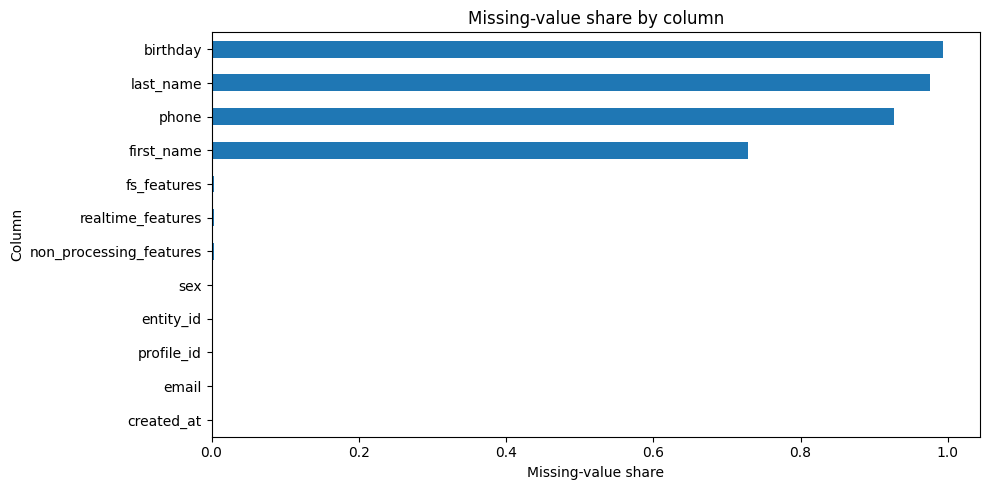

In [7]:
plt.figure(figsize=(10, 5))
missing_summary["missing_share"].sort_values().plot(kind="barh")
plt.title("Missing-value share by column")
plt.xlabel("Missing-value share")
plt.ylabel("Column")
plt.tight_layout()
plt.show()

### Findings

- Personal fields are highly incomplete: `birthday`, `last_name`, `phone`, and `first_name` are populated much less often than `email`.
- Simple rules such as "matching full name and date of birth" will therefore have low coverage and cannot serve as the primary duplicate-detection strategy.

## 5. Validating the `profile_id` and `entity_id` Keys

In [8]:
key_summary = pd.DataFrame({
    "metric": [
        "rows",
        "unique_profile_id",
        "unique_entity_id",
        "unique_email",
    ],
    "value": [
        len(df),
        df["profile_id"].nunique(dropna=False) if "profile_id" in df.columns else np.nan,
        df["entity_id"].nunique(dropna=False) if "entity_id" in df.columns else np.nan,
        df["email"].nunique(dropna=False) if "email" in df.columns else np.nan,
    ]
})

display(key_summary)

,metric,value
0,rows,68036
1,unique_profile_id,61927
2,unique_entity_id,53369
3,unique_email,61927


In [9]:
profile_entity_counts = (
    df.groupby("profile_id")["entity_id"]
    .nunique(dropna=False)
    .reset_index(name="n_unique_entity_id")
)

print("Distribution of entity_id counts per profile_id:")
display(profile_entity_counts["n_unique_entity_id"].value_counts().sort_index().to_frame("n_profile_id"))

bad_profiles = profile_entity_counts[profile_entity_counts["n_unique_entity_id"] > 1]
print(f"profile_id values linked to more than one entity_id: {len(bad_profiles):,}")

Distribution of entity_id counts per profile_id:


,n_profile_id
n_unique_entity_id,
1,61927


profile_id values linked to more than one entity_id: 0


In [10]:
entity_profile_counts_row_level = (
    df.groupby("entity_id")["profile_id"]
    .nunique(dropna=False)
    .reset_index(name="n_unique_profile_id")
)

print("Distribution of profile_id counts per entity_id:")
display(
    entity_profile_counts_row_level["n_unique_profile_id"]
    .value_counts()
    .sort_index()
    .reset_index()
    .rename(columns={"n_unique_profile_id": "cluster_size", "count": "n_entity_id"})
    .head(30)
)

n_duplicate_entities = int((entity_profile_counts_row_level["n_unique_profile_id"] > 1).sum())
print(f"entity_id values with multiple profile_id values: {n_duplicate_entities:,}")

Distribution of profile_id counts per entity_id:


,cluster_size,n_entity_id
0,1,45296
1,2,7808
2,3,227
3,4,26
4,5,4
5,6,3
6,7,1
7,10,1
8,22,1
9,37,1


entity_id values with multiple profile_id values: 8,073


### Findings

- The file contains **61,927 unique `profile_id` values** and **53,369 unique `entity_id` values**.
- The relationship is not one-to-one: one `entity_id` may contain several `profile_id` values.
- `email` is unique at the `profile_id` level, so exact matching on the full email address is not useful for finding duplicates across different profiles.

## 6. Repeated Rows for the Same `profile_id`

Before solving entity resolution, two phenomena must be separated:

1. repeated rows for the same `profile_id`;
2. different `profile_id` values belonging to the same `entity_id`.

The profile is the main object for customer matching, so the rows are aggregated to the `profile_id` level below.

,count,mean,std,min,25%,50%,75%,max
n_rows,61927.0,1.098648,0.539293,1.0,1.0,1.0,1.0,29.0


profile_id values appearing more than once: 3,705
Maximum rows for one profile_id: 29


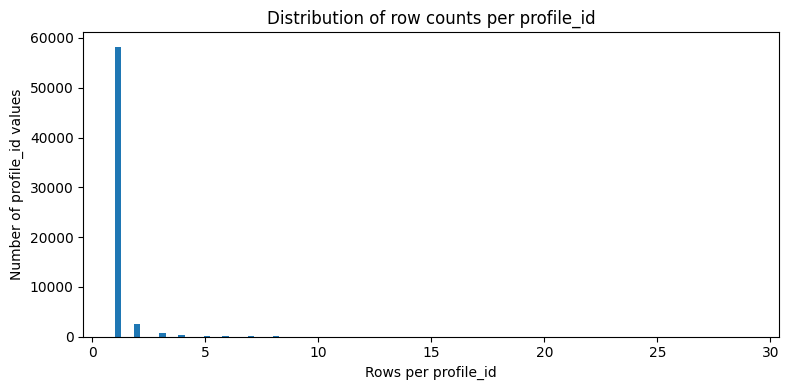

In [11]:
rows_per_profile = df.groupby("profile_id").size().rename("n_rows").reset_index()

display(rows_per_profile["n_rows"].describe().to_frame().T)
print(f"profile_id values appearing more than once: {(rows_per_profile['n_rows'] > 1).sum():,}")
print(f"Maximum rows for one profile_id: {rows_per_profile['n_rows'].max():,}")

plt.figure(figsize=(8, 4))
rows_per_profile["n_rows"].clip(upper=100).plot(kind="hist", bins=100)
plt.title("Distribution of row counts per profile_id")
plt.xlabel("Rows per profile_id")
plt.ylabel("Number of profile_id values")
plt.tight_layout()
plt.show()

### Findings

- The source file contains more rows than unique profiles: **68,036 rows versus 61,927 `profile_id` values**.
- **3,705 profiles** appear more than once; the maximum is **29 rows** for one profile.
- These repetitions should not be confused with duplicate profiles. They are most likely repeated observations, events, visits, updates, or snapshots of the same profile.

## 7. Profile-Level Aggregation

Create `profile_df`, where each row represents one `profile_id`.

In [12]:
def is_empty_value(x):
    """Checks for empty values, including None, NaN, empty strings, and empty arrays or lists."""
    if x is None:
        return True
    if isinstance(x, float) and np.isnan(x):
        return True
    if isinstance(x, str) and x.strip() == "":
        return True
    if isinstance(x, np.ndarray) and len(x) == 0:
        return True
    if isinstance(x, (list, tuple, set)) and len(x) == 0:
        return True
    return False

def to_hashable(x):
    if is_empty_value(x):
        return None
    if isinstance(x, (list, tuple, np.ndarray)):
        if isinstance(x, np.ndarray):
            x = x.tolist()
        return tuple(to_hashable(item) for item in x)
    if isinstance(x, dict):
        return tuple(sorted((k, to_hashable(v)) for k, v in x.items()))
    return x

def first_non_empty(series):
    for x in series:
        if not is_empty_value(x):
            return x
    return np.nan

def unique_non_empty_count(series):
    values = []
    for x in series:
        if not is_empty_value(x):
            values.append(to_hashable(x))
    return len(set(values))

def listify(x):
    if is_empty_value(x):
        return []
    if isinstance(x, np.ndarray):
        return list(x.tolist())
    if isinstance(x, (list, tuple, set)):
        return list(x)
    return [x]

def merge_unique_lists(series):
    result = []
    seen = set()
    for item in series:
        for token in listify(item):
            if is_empty_value(token):
                continue
            token = str(token)
            if token not in seen:
                seen.add(token)
                result.append(token)
    return result

In [13]:
profile_df = (
    df.groupby("profile_id", as_index=False)
      .agg(
          entity_id=("entity_id", first_non_empty),
          n_rows_per_profile=("profile_id", "size"),
          first_seen_at=("created_at", "min"),
          last_seen_at=("created_at", "max"),
          first_name=("first_name", first_non_empty),
          last_name=("last_name", first_non_empty),
          email=("email", first_non_empty),
          phone=("phone", first_non_empty),
          birthday=("birthday", first_non_empty),
          sex=("sex", first_non_empty),
          n_unique_first_name=("first_name", unique_non_empty_count),
          n_unique_last_name=("last_name", unique_non_empty_count),
          n_unique_email=("email", unique_non_empty_count),
          n_unique_phone=("phone", unique_non_empty_count),
          n_unique_birthday=("birthday", unique_non_empty_count),
          n_unique_sex=("sex", unique_non_empty_count),
          realtime_features=("realtime_features", first_non_empty),
          n_unique_realtime_features=("realtime_features", unique_non_empty_count),
          non_processing_features=("non_processing_features", merge_unique_lists),
          fs_features=("fs_features", merge_unique_lists),
      )
)

profile_df["profile_lifetime_days"] = (
    profile_df["last_seen_at"] - profile_df["first_seen_at"]
).dt.total_seconds() / 86400

print(f"Source table: {df.shape[0]:,} rows")
print(f"Profile-level table: {profile_df.shape[0]:,} rows")
print(f"Unique profile_id values in source data: {df['profile_id'].nunique():,}")

assert len(profile_df) == df["profile_id"].nunique(), "Aggregation error: row count does not equal the number of unique profile_id values"

display(profile_df.head())

Source table: 68,036 rows
Profile-level table: 61,927 rows
Unique profile_id values in source data: 61,927


,profile_id,entity_id,n_rows_per_profile,first_seen_at,last_seen_at,first_name,last_name,email,phone,birthday,sex,n_unique_first_name,n_unique_last_name,n_unique_email,n_unique_phone,n_unique_birthday,n_unique_sex,realtime_features,n_unique_realtime_features,non_processing_features,fs_features,profile_lifetime_days
0,000163e0-b9b4-3323-84ea-6495df7fe895,266eb686284a35db45a797ef75c01fc276e71fee1eb2aaaf71d3606a64b91aeb,1,2026-05-09 07:47:48.739,2026-05-09 07:47:48.739,NaN,NaN,srnxztxqa8004@gmail.com,NaN,NaT,unknown,0,0,1,0,1,1,"{""country"":""BY"",""is_million"":true,""visit_count"":""0"",""tz_offset"":3,""geoname"":""Minsk"",""geoid"":625144,""local_hour"":10,""day"":5,""population"":1742124}",1,"[geoname_id:625144, subdivision_1_iso_code:HM, is_not_russia, browser:chrome, device:smartphone, osfamily:android]",[],0.0
1,0001ced1-cecc-3dc9-b4c1-acf162c8b2b5,ef07a5be121a62611f6b1f7e25fed25a0d02b9571d7bbcfb0370ff164dd1bbd4,1,2026-01-26 13:13:07.558,2026-01-26 13:13:07.558,NaN,NaN,wjpfhmp@vk.com,79959678942,NaT,unknown,0,0,1,1,1,1,{},1,"[device:smartphone, is_not_russia, osfamily:ios]","[mm_event_90:sent, mm_event_30:sent, postman_campaign_30:workflow, has_click_365:3827, source_site_365:6329, has_accept_365:3827, postman_action_90:smtp_lin...",0.0
2,0002ac9a-fd3f-31a7-9ab5-77b1d3961382,244363f995686f034394129500ab9c06fa262eefa04cfc1c3bb554f1227f2f9c,1,2026-03-06 15:45:40.523,2026-03-06 15:45:40.523,Василиса,NaN,qleopvd052996@gmail.com,NaN,NaT,unknown,1,0,1,0,1,1,{},1,"[osfamily:android, subdivision_1_iso_code:KR, device:smartphone, browser:chrome]",[source_site_365:6976],0.0
3,00036d8f-9320-39b0-96e9-f0a457fc82a4,5b3e5b68690777e70e9f394d45ebb85aeb5f12c68b2f0656e2ca6358a8a01eb8,1,2026-04-01 22:57:18.942,2026-04-01 22:57:18.942,NaN,NaN,hxubxrhcy67@inbox.ru,NaN,NaT,unknown,0,0,1,0,1,1,"{""country"":""RU"",""is_million"":false,""visit_count"":""21"",""tz_offset"":3,""geoname"":""Kursk"",""geoid"":538560,""local_hour"":1,""day"":3,""population"":448733}",1,"[osfamily:android, subdivision_1_iso_code:KRS, browser:chrome, device:smartphone, geoname_id:538560]","[has_accept_30:6592, has_view_90:5553, has_view_90:6592, has_view_90:3756, has_view_90:6980, has_view_90:6780, visited_30:1345, has_view_90:6914, has_accoun...",0.0
4,0003e46e-fc6c-34a8-8358-606d66c1eec2,eb99135fb3e4af6723c6daf1ac22f4f9c15218c3f17a5324daef53e70032a8da,1,2026-02-10 13:34:15.506,2026-02-10 13:34:15.506,NaN,NaN,lxhsidqbzwloh588@gmail.com,NaN,NaT,unknown,0,0,1,0,1,1,"{""country"":""UZ"",""is_million"":true,""tz_offset"":5,""geoname"":""Tashkent"",""geoid"":1512569,""local_hour"":18,""day"":1,""population"":1978028}",1,"[browser:chrome, osfamily:android, device:smartphone, geoname_id:1512569, is_not_russia, subdivision_1_iso_code:TK]",[],0.0


### Findings

- `entity_id` is retained as the target label, while `created_at` is aggregated into `first_seen_at` and `last_seen_at` to preserve the profile's temporal context.
- For list-valued features (`non_processing_features`, `fs_features`), combining unique tokens within a profile is more appropriate than taking only the first value.

## 8. Enriching `profile_df`: Field Normalization and Completeness Features

In [14]:
def normalize_text(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip().lower()
    x = re.sub(r"\s+", " ", x)
    return x if x else np.nan


def email_local_part(email):
    if pd.isna(email):
        return np.nan
    email = str(email).strip().lower()
    if "@" not in email:
        return np.nan
    return email.split("@", 1)[0]


def email_domain(email):
    if pd.isna(email):
        return np.nan
    email = str(email).strip().lower()
    if "@" not in email:
        return np.nan
    return email.split("@", 1)[1]


def normalize_phone(phone):
    if pd.isna(phone):
        return np.nan
    digits = re.sub(r"\D", "", str(phone))
    if len(digits) == 11 and digits.startswith("8"):
        digits = "7" + digits[1:]
    return digits if digits else np.nan


def safe_birth_year(x):
    if pd.isna(x):
        return np.nan
    try:
        return pd.to_datetime(x).year
    except Exception:
        return np.nan

profile_df["first_name_norm"] = profile_df["first_name"].map(normalize_text)
profile_df["last_name_norm"] = profile_df["last_name"].map(normalize_text)
profile_df["email_norm"] = profile_df["email"].astype(str).str.strip().str.lower()
profile_df["email_local"] = profile_df["email"].map(email_local_part)
profile_df["email_domain"] = profile_df["email"].map(email_domain)
profile_df["phone_norm"] = profile_df["phone"].map(normalize_phone)
profile_df["birth_year"] = profile_df["birthday"].map(safe_birth_year)
profile_df["sex_norm"] = profile_df["sex"].map(normalize_text)

profile_df["has_first_name"] = profile_df["first_name_norm"].notna()
profile_df["has_last_name"] = profile_df["last_name_norm"].notna()
profile_df["has_email"] = profile_df["email_norm"].notna()
profile_df["has_phone"] = profile_df["phone_norm"].notna()
profile_df["has_birthday"] = profile_df["birth_year"].notna()
profile_df["has_known_sex"] = profile_df["sex_norm"].notna() & ~profile_df["sex_norm"].isin(["unknown", "none", "nan"])

identity_presence_cols = [
    "has_first_name",
    "has_last_name",
    "has_email",
    "has_phone",
    "has_birthday",
    "has_known_sex",
]

profile_df["identity_completeness_score"] = profile_df[identity_presence_cols].sum(axis=1)

entity_profile_counts = profile_df.groupby("entity_id")["profile_id"].nunique().rename("n_profiles_in_entity")
profile_df = profile_df.merge(entity_profile_counts, on="entity_id", how="left")
profile_df["is_duplicate_entity"] = profile_df["n_profiles_in_entity"] > 1

profile_df[[
    "profile_id", "entity_id", "first_seen_at", "email", "email_domain", "phone_norm",
    "identity_completeness_score", "n_profiles_in_entity", "is_duplicate_entity"
]].head()

,profile_id,entity_id,first_seen_at,email,email_domain,phone_norm,identity_completeness_score,n_profiles_in_entity,is_duplicate_entity
0,000163e0-b9b4-3323-84ea-6495df7fe895,266eb686284a35db45a797ef75c01fc276e71fee1eb2aaaf71d3606a64b91aeb,2026-05-09 07:47:48.739,srnxztxqa8004@gmail.com,gmail.com,NaN,1,1,False
1,0001ced1-cecc-3dc9-b4c1-acf162c8b2b5,ef07a5be121a62611f6b1f7e25fed25a0d02b9571d7bbcfb0370ff164dd1bbd4,2026-01-26 13:13:07.558,wjpfhmp@vk.com,vk.com,79959678942,2,1,False
2,0002ac9a-fd3f-31a7-9ab5-77b1d3961382,244363f995686f034394129500ab9c06fa262eefa04cfc1c3bb554f1227f2f9c,2026-03-06 15:45:40.523,qleopvd052996@gmail.com,gmail.com,NaN,2,1,False
3,00036d8f-9320-39b0-96e9-f0a457fc82a4,5b3e5b68690777e70e9f394d45ebb85aeb5f12c68b2f0656e2ca6358a8a01eb8,2026-04-01 22:57:18.942,hxubxrhcy67@inbox.ru,inbox.ru,NaN,1,1,False
4,0003e46e-fc6c-34a8-8358-606d66c1eec2,eb99135fb3e4af6723c6daf1ac22f4f9c15218c3f17a5324daef53e70032a8da,2026-02-10 13:34:15.506,lxhsidqbzwloh588@gmail.com,gmail.com,NaN,1,1,False


### Findings

- Email was split into the local part and domain, phone numbers were converted to a consistent numeric format, and text fields were lowercased and stripped of extra whitespace.
- For sex, `unknown` must be distinguished from actual `male` and `female` values: `unknown == unknown` should not be treated as a strong positive signal.
- `identity_completeness_score` is a potential predictor of duplication probability.
- The model should use both field values and presence flags such as `has_phone`, `has_first_name`, `has_birthday`, and `has_known_sex`.

## 9. Profile-Level Missing Values and Completeness

In [15]:
profile_missing_summary = (
    pd.DataFrame({
        "missing_count": profile_df.isna().sum(),
        "missing_share": profile_df.isna().mean(),
        "non_missing_count": profile_df.notna().sum(),
    })
    .sort_values("missing_share", ascending=False)
)

display(profile_missing_summary.head(30).style.format({"missing_share": "{:.2%}"}))

,missing_count,missing_share,non_missing_count
birthday,61558,99.40%,369
birth_year,61558,99.40%,369
last_name,60440,97.60%,1487
last_name_norm,60440,97.60%,1487
phone_norm,57271,92.48%,4656
phone,57271,92.48%,4656
first_name_norm,44885,72.48%,17042
first_name,44885,72.48%,17042
realtime_features,215,0.35%,61712
sex_norm,47,0.08%,61880


,identity_completeness_score,n_profiles,duplicate_rate,n_duplicate_profiles
0,1,39439,31.00%,12228
1,2,7413,23.28%,1726
2,3,12205,18.07%,2205
3,4,2470,16.68%,412
4,5,361,14.96%,54
5,6,39,15.38%,6


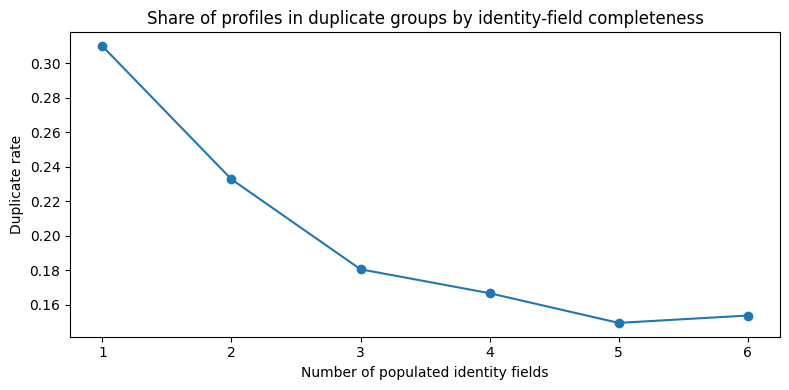

In [16]:
completeness_summary = (
    profile_df.groupby("identity_completeness_score")
    .agg(
        n_profiles=("profile_id", "size"),
        duplicate_rate=("is_duplicate_entity", "mean"),
        n_duplicate_profiles=("is_duplicate_entity", "sum"),
    )
    .reset_index()
)

display(completeness_summary.style.format({"duplicate_rate": "{:.2%}"}))

plt.figure(figsize=(8, 4))
plt.plot(completeness_summary["identity_completeness_score"], completeness_summary["duplicate_rate"], marker="o")
plt.title("Share of profiles in duplicate groups by identity-field completeness")
plt.xlabel("Number of populated identity fields")
plt.ylabel("Duplicate rate")
plt.tight_layout()
plt.show()

### Findings

- At the profile level, `birthday` is missing for approximately **99.4%**, `last_name` for **97.6%**, `phone` for **92.5%**, and `first_name` for **72.5%** of profiles.
- `email` is populated for every profile, but each full email value is unique to one `profile_id`.
- Profiles with fewer populated identity fields have a higher duplicate rate: it is approximately **31%** for the least complete profiles and noticeably lower for more complete profiles.
- **This confirms an important pattern: duplicates occur more often among incomplete, weakly identifiable profiles.**

## 10. True Duplicate-Cluster Sizes

If one `entity_id` contains several `profile_id` values, those profiles belong to the same real customer.

In [17]:
cluster_size_distribution = (
    profile_df[["entity_id", "n_profiles_in_entity"]]
    .drop_duplicates()
    ["n_profiles_in_entity"]
    .value_counts()
    .sort_index()
    .reset_index()
)
cluster_size_distribution.columns = ["cluster_size", "n_entities"]

display(cluster_size_distribution.head(30))

n_entities = profile_df["entity_id"].nunique()
n_duplicate_entities = int((cluster_size_distribution.loc[cluster_size_distribution["cluster_size"] > 1, "n_entities"]).sum())
n_profiles_in_duplicate_entities = int(profile_df["is_duplicate_entity"].sum())

print(f"Total entity_id values: {n_entities:,}")
print(f"entity_id values with multiple profile_id values: {n_duplicate_entities:,}")
print(f"Profiles in duplicate groups: {n_profiles_in_duplicate_entities:,}")
print(f"Share of profiles in duplicate groups: {profile_df['is_duplicate_entity'].mean():.2%}")
print(f"Maximum cluster size: {profile_df['n_profiles_in_entity'].max():,}")

,cluster_size,n_entities
0,1,45296
1,2,7808
2,3,227
3,4,26
4,5,4
5,6,3
6,7,1
7,10,1
8,22,1
9,37,1


Total entity_id values: 53,369
entity_id values with multiple profile_id values: 8,073
Profiles in duplicate groups: 16,631
Share of profiles in duplicate groups: 26.86%
Maximum cluster size: 116


<Figure size 1000x400 with 0 Axes>

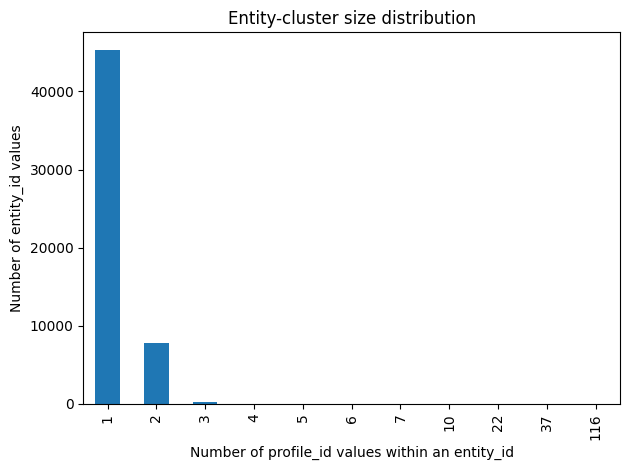

In [18]:
plt.figure(figsize=(10, 4))
cluster_size_distribution[cluster_size_distribution["cluster_size"] <= 1000].plot(
    x="cluster_size", y="n_entities", kind="bar", legend=False
)
plt.title("Entity-cluster size distribution")
plt.xlabel("Number of profile_id values within an entity_id")
plt.ylabel("Number of entity_id values")
plt.tight_layout()
plt.show()

### Findings

- **8,073 `entity_id` values** contain more than one `profile_id`; these are labeled duplicate groups.
- Duplicate groups contain **16,631 profiles**, or **26.86%** of all profiles.
- Most duplicate clusters have size 2, but some are large; the maximum is **116 profiles** for one `entity_id`.

## 11. Field Stability Within Duplicate Groups

This section checks which fields change within one `entity_id`. The results help distinguish stable identifiers from fields that frequently differ across duplicates.

In [19]:
def nunique_non_missing(s):
    return s.dropna().nunique()

fields_to_check = [
    "email", "email_domain", "email_local", "phone_norm", "first_name_norm", "last_name_norm", "birth_year", "sex_norm"
]

duplicate_profiles = profile_df[profile_df["is_duplicate_entity"]].copy()

variation_rows = []
for col in fields_to_check:
    nun = duplicate_profiles.groupby("entity_id")[col].apply(nunique_non_missing)
    variation_rows.append({
        "field": col,
        "duplicate_groups": len(nun),
        "groups_with_0_non_missing_values": int((nun == 0).sum()),
        "groups_with_1_non_missing_value": int((nun == 1).sum()),
        "groups_with_2plus_values": int((nun > 1).sum()),
        "share_groups_with_2plus_values": float((nun > 1).mean()),
        "share_groups_with_0_values": float((nun == 0).mean()),
    })

variation_summary = pd.DataFrame(variation_rows).sort_values("share_groups_with_2plus_values", ascending=False)
display(variation_summary.style.format({
    "share_groups_with_2plus_values": "{:.2%}",
    "share_groups_with_0_values": "{:.2%}",
}))

,field,duplicate_groups,groups_with_0_non_missing_values,groups_with_1_non_missing_value,groups_with_2plus_values,share_groups_with_2plus_values,share_groups_with_0_values
0,email,8073,0,0,8073,100.00%,0.00%
2,email_local,8073,0,0,8073,100.00%,0.00%
1,email_domain,8073,0,3778,4295,53.20%,0.00%
7,sex_norm,8073,3,5755,2315,28.68%,0.04%
4,first_name_norm,8073,5409,2430,234,2.90%,67.00%
3,phone_norm,8073,7395,627,51,0.63%,91.60%
5,last_name_norm,8073,7776,291,6,0.07%,96.32%
6,birth_year,8073,8003,70,0,0.00%,99.13%


### Findings

- Full email addresses differ in every duplicate group, so exact email matching does not solve the task.
- `phone`, `birthday`, and `last_name` rarely vary within duplicate groups, mainly because their coverage is low.
- `sex` differs or changes in informativeness in a meaningful share of duplicate groups.

## 12. Email Analysis

In this dataset, email may be unique at the profile level, so exact email matching may not find duplicates. Email is more useful as a source of derived features: domain, local part, digit presence, length, separators, and local-part similarity.

In [20]:
email_summary = pd.DataFrame({
    "metric": [
        "profiles",
        "unique_email",
        "unique_email_domain",
        "email_missing_share",
    ],
    "value": [
        len(profile_df),
        profile_df["email_norm"].nunique(dropna=False),
        profile_df["email_domain"].nunique(dropna=False),
        profile_df["email_norm"].isna().mean(),
    ]
})

display(email_summary)

email_profile_counts = profile_df.groupby("email_norm")["profile_id"].nunique().sort_values(ascending=False)
print("Maximum profile_id count for one email:", int(email_profile_counts.max()))
print("Email addresses shared by multiple profile_id values:", int((email_profile_counts > 1).sum()))

,metric,value
0,profiles,61927.0
1,unique_email,61927.0
2,unique_email_domain,780.0
3,email_missing_share,0.0


Maximum profile_id count for one email: 1
Email addresses shared by multiple profile_id values: 0


,email_domain,n_profiles
0,gmail.com,31253
1,mail.ru,15314
2,yandex.ru,7416
3,icloud.com,1556
4,bk.ru,1492
5,list.ru,741
6,inbox.ru,676
7,rambler.ru,453
8,internet.ru,313
9,ya.ru,308


<Figure size 900x500 with 0 Axes>

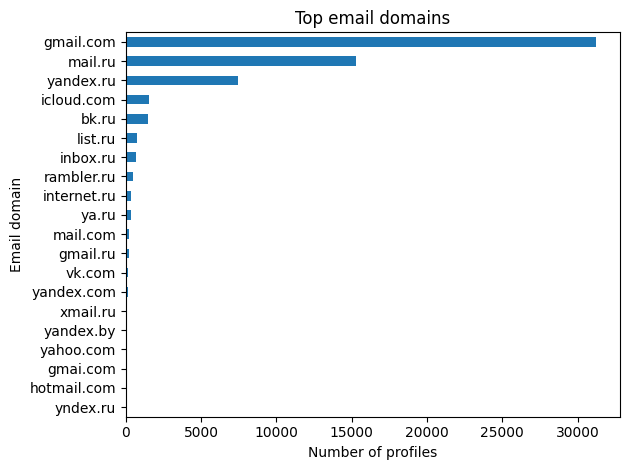

In [21]:
top_domains = profile_df["email_domain"].value_counts(dropna=False).head(20).reset_index()
top_domains.columns = ["email_domain", "n_profiles"]
display(top_domains)

plt.figure(figsize=(9, 5))
top_domains.sort_values("n_profiles").plot(x="email_domain", y="n_profiles", kind="barh", legend=False)
plt.title("Top email domains")
plt.xlabel("Number of profiles")
plt.ylabel("Email domain")
plt.tight_layout()
plt.show()

In [22]:
email_domain_dup_rate = (
    profile_df.groupby("email_domain")
    .agg(
        n_profiles=("profile_id", "size"),
        duplicate_rate=("is_duplicate_entity", "mean"),
        n_duplicate_profiles=("is_duplicate_entity", "sum"),
    )
    .query("n_profiles >= 100")
    .sort_values("duplicate_rate", ascending=False)
)

display(email_domain_dup_rate.head(20).style.format({"duplicate_rate": "{:.2%}"}))

,n_profiles,duplicate_rate,n_duplicate_profiles
email_domain,,,
gmail.ru,203,54.19%,110
yandex.com,116,52.59%,61
ya.ru,308,45.78%,141
mail.com,211,43.13%,91
yandex.ru,7416,30.93%,2294
internet.ru,313,29.07%,91
vk.com,119,28.57%,34
icloud.com,1556,27.51%,428
gmail.com,31253,26.38%,8246


In [23]:
email_domains_per_entity = (
    duplicate_profiles.groupby("entity_id")["email_domain"]
    .nunique(dropna=True)
    .rename("n_email_domains")
    .reset_index()
)

display(email_domains_per_entity["n_email_domains"].value_counts().sort_index().to_frame("n_entities"))
print("Share of duplicate groups with more than one email domain:", (email_domains_per_entity["n_email_domains"] > 1).mean())

,n_entities
n_email_domains,
1,3778
2,4237
3,55
4,2
5,1


Share of duplicate groups with more than one email domain: 0.5320203146290102


### Findings

- The full email address is unique to each `profile_id`, so exact email matching is practically useless for duplicate detection.
- Email's main value lies in derived features: domain, domain group, local-part similarity, digits, separators, local-part length, and matching or similar patterns.
- Pairs such as `gmail.com` versus `googlemail.com` and `yandex.ru` versus `ya.ru` should be checked separately.

## 13. Phone Number

A phone number is often a strong identifier, but coverage may be low in noisy customer databases. This section checks completeness, repetition, and overlap across `entity_id` values.

In [24]:
phone_stats = pd.DataFrame({
    "metric": [
        "profiles",
        "profiles_with_phone",
        "phone_coverage",
        "unique_phone",
        "phones_used_by_multiple_profiles",
    ],
    "value": [
        len(profile_df),
        int(profile_df["phone_norm"].notna().sum()),
        profile_df["phone_norm"].notna().mean(),
        profile_df["phone_norm"].nunique(dropna=True),
        int((profile_df.groupby("phone_norm")["profile_id"].nunique() > 1).sum()),
    ]
})

display(phone_stats)

,metric,value
0,profiles,61927.000000
1,profiles_with_phone,4656.000000
2,phone_coverage,0.075185
3,unique_phone,4578.000000
4,phones_used_by_multiple_profiles,78.000000


In [25]:
phone_entity_counts = (
    profile_df.dropna(subset=["phone_norm"])
    .groupby("phone_norm")["entity_id"]
    .nunique()
    .sort_values(ascending=False)
)

print("Maximum entity_id count for one phone_norm:", int(phone_entity_counts.max()) if len(phone_entity_counts) else 0)
print("Phone numbers linked to multiple entity_id values:", int((phone_entity_counts > 1).sum()) if len(phone_entity_counts) else 0)

display(phone_entity_counts.head(10).to_frame("n_entity_id"))

Maximum entity_id count for one phone_norm: 1
Phone numbers linked to multiple entity_id values: 0


,n_entity_id
phone_norm,
77003500958,1
79522267548,1
79522576316,1
79522500880,1
79522488031,1
79522407215,1
79522365908,1
79522328418,1
79522258619,1


### Findings

- The same phone number does not span different `entity_id` values, making an exact normalized-phone match a potentially high-precision signal.
- Phone is suitable as a high-precision match signal, but the large number of missing values prevents it from being the only basis for candidate selection.
- Phone numbers should be normalized and exact-matched; Levenshtein similarity is unnecessary for phone numbers.

## 14. Name, Sex, and Date of Birth

,field,coverage
5,email,100.00%
4,known_sex,27.97%
0,first_name,27.52%
2,phone,7.52%
1,last_name,2.40%
3,birthday,0.60%


<Figure size 800x400 with 0 Axes>

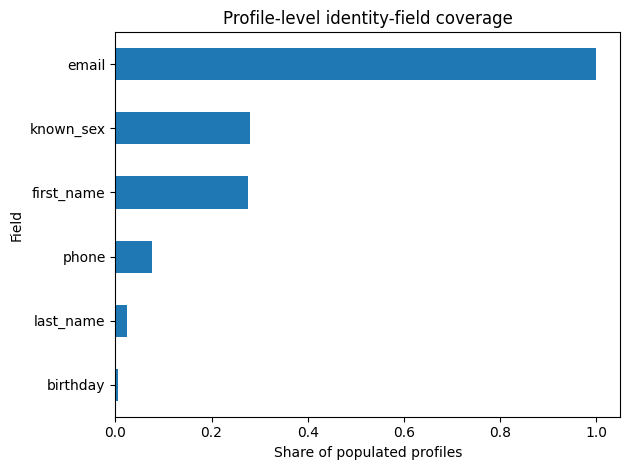

In [26]:
identity_field_coverage = pd.DataFrame({
    "field": ["first_name", "last_name", "phone", "birthday", "known_sex", "email"],
    "coverage": [
        profile_df["has_first_name"].mean(),
        profile_df["has_last_name"].mean(),
        profile_df["has_phone"].mean(),
        profile_df["has_birthday"].mean(),
        profile_df["has_known_sex"].mean(),
        profile_df["has_email"].mean(),
    ]
}).sort_values("coverage", ascending=False)

display(identity_field_coverage.style.format({"coverage": "{:.2%}"}))

plt.figure(figsize=(8, 4))
identity_field_coverage.sort_values("coverage").plot(x="field", y="coverage", kind="barh", legend=False)
plt.title("Profile-level identity-field coverage")
plt.xlabel("Share of populated profiles")
plt.ylabel("Field")
plt.tight_layout()
plt.show()

In [27]:
print("sex_norm distribution:")
display(profile_df["sex_norm"].fillna("<missing>").value_counts(dropna=False).to_frame("n_profiles"))

print("Top first_name_norm values:")
display(profile_df["first_name_norm"].value_counts().head(20).to_frame("n_profiles"))

print("Top last_name_norm values:")
display(profile_df["last_name_norm"].value_counts().head(20).to_frame("n_profiles"))

sex_norm distribution:


,n_profiles
sex_norm,
unknown,44562
female,9170
male,8148
<missing>,47


Top first_name_norm values:


,n_profiles
first_name_norm,
артём,1542
алевтина,1428
александр,1201
зоя,1119
василиса,857
елизавета,728
егор,587
кира,562
георгий,522


Top last_name_norm values:


,n_profiles
last_name_norm,
гусева,13
владимиров,11
симонова,10
третьяков,9
котова,9
иванова,9
архипова,9
уварова,8
селезнева,8


### Findings

- Name and date of birth cannot be the primary duplicate-detection method, but they can provide strong supporting signals when populated.
- `sex` is `unknown` for approximately **72%** of profiles. Matching two `unknown` values is almost uninformative, while a conflict between two known values may be a negative signal.

## 15. Temporal Patterns in Duplicate Creation

This section analyzes when profiles in duplicate groups appear and how much time passes between the first and last profile within one `entity_id`.

In [28]:
profile_df["first_seen_date"] = profile_df["first_seen_at"].dt.date
profile_df["first_seen_hour"] = profile_df["first_seen_at"].dt.hour
profile_df["first_seen_weekday"] = profile_df["first_seen_at"].dt.day_name()

created_daily = (
    profile_df.groupby("first_seen_date")
    .agg(
        n_profiles=("profile_id", "size"),
        duplicate_rate=("is_duplicate_entity", "mean"),
        n_duplicate_profiles=("is_duplicate_entity", "sum"),
    )
    .reset_index()
)

display(created_daily.head())

,first_seen_date,n_profiles,duplicate_rate,n_duplicate_profiles
0,2025-11-01,378,0.246032,93
1,2025-11-02,326,0.260736,85
2,2025-11-03,289,0.252595,73
3,2025-11-04,245,0.318367,78
4,2025-11-05,266,0.274436,73


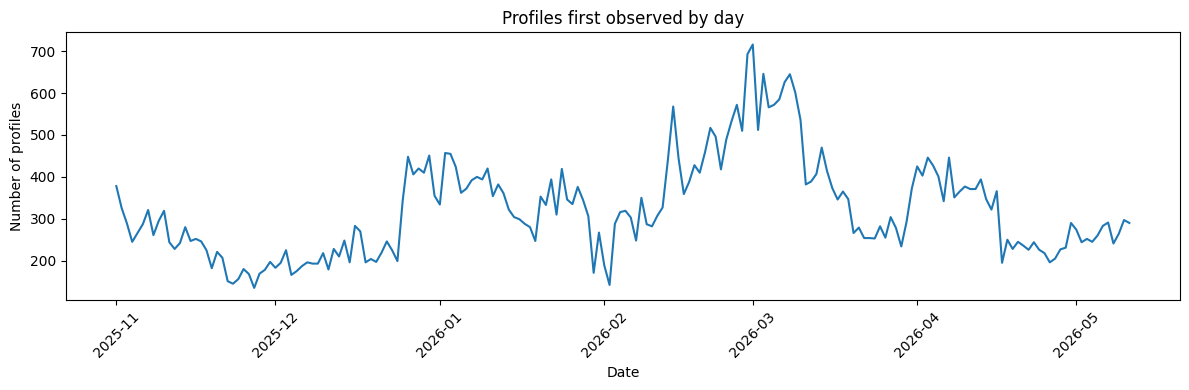

In [29]:
plt.figure(figsize=(12, 4))
plt.plot(created_daily["first_seen_date"], created_daily["n_profiles"])
plt.title("Profiles first observed by day")
plt.xlabel("Date")
plt.ylabel("Number of profiles")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

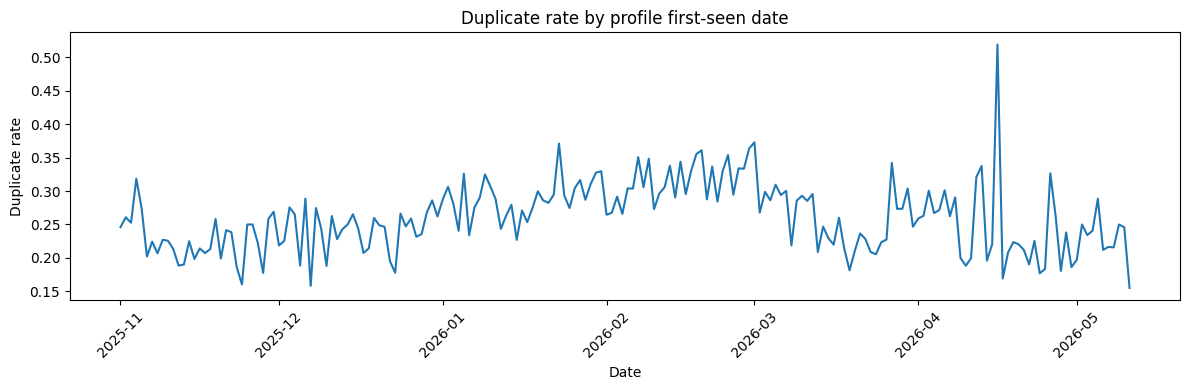

In [30]:
plt.figure(figsize=(12, 4))
plt.plot(created_daily["first_seen_date"], created_daily["duplicate_rate"])
plt.title("Duplicate rate by profile first-seen date")
plt.xlabel("Date")
plt.ylabel("Duplicate rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

,count,mean,std,min,25%,50%,75%,max
span_days,8073.0,31.564068,38.505079,0.000177,0.00362,15.497145,53.280281,187.359589


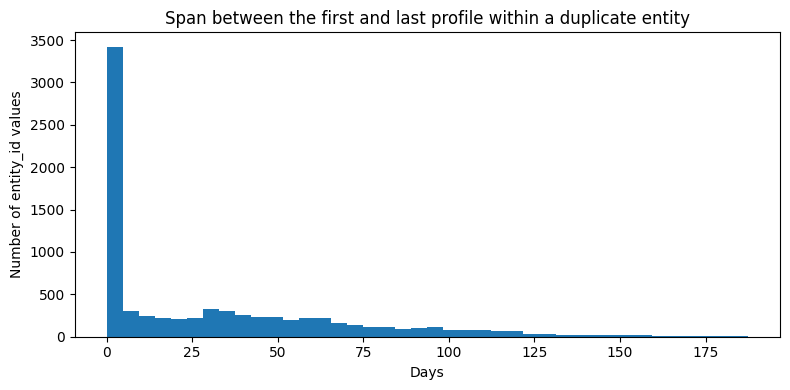

In [31]:
entity_time_span = (
    profile_df.groupby("entity_id")
    .agg(
        n_profiles=("profile_id", "nunique"),
        first_profile_seen=("first_seen_at", "min"),
        last_profile_seen=("first_seen_at", "max"),
    )
)
entity_time_span["span_days"] = (
    entity_time_span["last_profile_seen"] - entity_time_span["first_profile_seen"]
).dt.total_seconds() / 86400

entity_time_span_dup = entity_time_span[entity_time_span["n_profiles"] > 1]

display(entity_time_span_dup["span_days"].describe().to_frame().T)

plt.figure(figsize=(8, 4))
entity_time_span_dup["span_days"].clip(upper=1000).plot(kind="hist", bins=40)
plt.title("Span between the first and last profile within a duplicate entity")
plt.xlabel("Days")
plt.ylabel("Number of entity_id values")
plt.tight_layout()
plt.show()

### Findings

- A quarter of duplicate groups are created almost simultaneously, while others span months, suggesting different duplicate-creation mechanisms.

## 16. Parsing `realtime_features`

`realtime_features` is stored as a JSON string or dictionary. It is parsed into separate features such as country, city, geoid, timezone, local hour, and population.

In [32]:
def parse_realtime(x):
    if is_empty_value(x):
        return {}
    if isinstance(x, dict):
        return x
    if isinstance(x, str):
        try:
            parsed = json.loads(x)
            return parsed if isinstance(parsed, dict) else {}
        except Exception:
            return {}
    return {}

realtime_dicts = profile_df["realtime_features"].map(parse_realtime)
realtime_df = pd.json_normalize(realtime_dicts).add_prefix("rt_")

profile_df = pd.concat([profile_df.reset_index(drop=True), realtime_df.reset_index(drop=True)], axis=1)

print("Parsed real-time columns:")
print([c for c in profile_df.columns if c.startswith("rt_")])

display(profile_df[["profile_id", "rt_country", "rt_geoname", "rt_geoid", "rt_tz_offset", "rt_local_hour"]].head())

Parsed real-time columns:
['rt_country', 'rt_is_million', 'rt_visit_count', 'rt_tz_offset', 'rt_geoname', 'rt_geoid', 'rt_local_hour', 'rt_day', 'rt_population']


,profile_id,rt_country,rt_geoname,rt_geoid,rt_tz_offset,rt_local_hour
0,000163e0-b9b4-3323-84ea-6495df7fe895,BY,Minsk,625144.0,3.0,10.0
1,0001ced1-cecc-3dc9-b4c1-acf162c8b2b5,NaN,NaN,NaN,NaN,NaN
2,0002ac9a-fd3f-31a7-9ab5-77b1d3961382,NaN,NaN,NaN,NaN,NaN
3,00036d8f-9320-39b0-96e9-f0a457fc82a4,RU,Kursk,538560.0,3.0,1.0
4,0003e46e-fc6c-34a8-8358-606d66c1eec2,UZ,Tashkent,1512569.0,5.0,18.0


In [33]:
rt_cols = [c for c in profile_df.columns if c.startswith("rt_")]
rt_missing = profile_df[rt_cols].isna().mean().sort_values(ascending=False).to_frame("missing_share")
display(rt_missing.style.format({"missing_share": "{:.2%}"}))

,missing_share
rt_visit_count,74.24%
rt_tz_offset,20.99%
rt_is_million,20.69%
rt_population,20.69%
rt_country,20.64%
rt_geoname,20.64%
rt_geoid,20.64%
rt_local_hour,20.64%
rt_day,20.64%


In [34]:
if "rt_geoname" in profile_df.columns:
    geo_dup_rate = (
        profile_df.groupby("rt_geoname")
        .agg(
            n_profiles=("profile_id", "size"),
            duplicate_rate=("is_duplicate_entity", "mean"),
            n_duplicate_profiles=("is_duplicate_entity", "sum"),
        )
        .query("n_profiles >= 100")
        .sort_values("duplicate_rate", ascending=False)
    )
    display(geo_dup_rate.head(20).style.format({"duplicate_rate": "{:.2%}"}))

,n_profiles,duplicate_rate,n_duplicate_profiles
rt_geoname,,,
Ulyanovsk,487,48.67%,237
Donetsk,306,38.56%,118
Poplar,102,38.24%,39
Taganrog,121,38.02%,46
Samarkand,372,36.83%,137
Luhansk,173,35.26%,61
Tashkent,1557,34.81%,542
Karagandy,106,33.96%,36
Tula,271,33.95%,92


### Findings

- Approximately **20%** of profiles lack complete real-time context, so these fields also need presence and absence indicators.
- Geography can act as a soft signal: matching city or region increases match probability, but a mismatch should not always prevent a merge.
- These features are especially important for profiles without a phone number, last name, or date of birth.

## 17. Parsing `non_processing_features`

,token,n_profiles
0,device:smartphone,54864
1,osfamily:android,39709
2,browser:chrome,32478
3,is_not_russia,17576
4,osfamily:ios,15457
5,browser:yandex,7685
6,device:pc,5023
7,osfamily:windows,4372
8,subdivision_1_iso_code:KDA,1914
9,subdivision_1_iso_code:SVE,1875


<Figure size 1000x600 with 0 Axes>

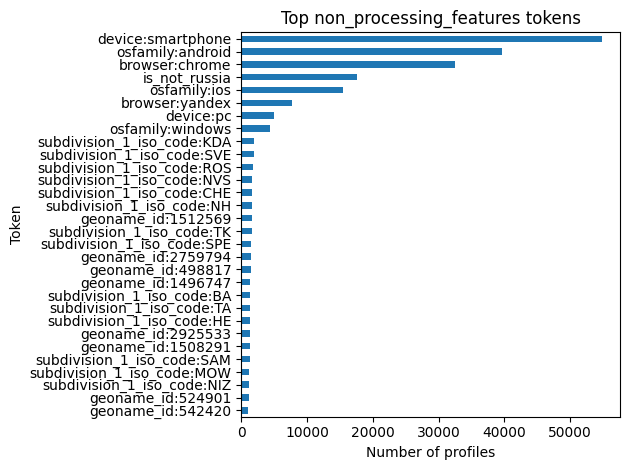

In [35]:
def unique_tokens(x):
    return sorted(set(str(t) for t in listify(x) if not is_empty_value(t)))

profile_df["np_tokens"] = profile_df["non_processing_features"].map(unique_tokens)
profile_df["fs_tokens"] = profile_df["fs_features"].map(unique_tokens)

all_np_tokens = Counter(token for tokens in profile_df["np_tokens"] for token in tokens)
np_token_freq = pd.DataFrame(all_np_tokens.most_common(30), columns=["token", "n_profiles"])
display(np_token_freq)

plt.figure(figsize=(10, 6))
np_token_freq.sort_values("n_profiles").plot(x="token", y="n_profiles", kind="barh", legend=False)
plt.title("Top non_processing_features tokens")
plt.xlabel("Number of profiles")
plt.ylabel("Token")
plt.tight_layout()
plt.show()

In [36]:
def extract_token_value(tokens, prefix):
    prefix = prefix + ":"
    for token in tokens:
        if str(token).startswith(prefix):
            return str(token).split(":", 1)[1]
    return np.nan

for prefix, col in [
    ("device", "np_device"),
    ("browser", "np_browser"),
    ("osfamily", "np_osfamily"),
    ("geoname_id", "np_geoname_id"),
    ("subdivision_1_iso_code", "np_region_iso"),
]:
    profile_df[col] = profile_df["np_tokens"].map(lambda tokens, p=prefix: extract_token_value(tokens, p))

tech_cols = ["np_device", "np_browser", "np_osfamily", "np_geoname_id", "np_region_iso"]
display(profile_df[["profile_id"] + tech_cols].head())

,profile_id,np_device,np_browser,np_osfamily,np_geoname_id,np_region_iso
0,000163e0-b9b4-3323-84ea-6495df7fe895,smartphone,chrome,android,625144,HM
1,0001ced1-cecc-3dc9-b4c1-acf162c8b2b5,smartphone,NaN,ios,NaN,NaN
2,0002ac9a-fd3f-31a7-9ab5-77b1d3961382,smartphone,chrome,android,NaN,KR
3,00036d8f-9320-39b0-96e9-f0a457fc82a4,smartphone,chrome,android,538560,KRS
4,0003e46e-fc6c-34a8-8358-606d66c1eec2,smartphone,chrome,android,1512569,TK


In [37]:
for col in tech_cols:
    print(f"\n{col}")
    rate = (
        profile_df.groupby(col)
        .agg(
            n_profiles=("profile_id", "size"),
            duplicate_rate=("is_duplicate_entity", "mean"),
        )
        .query("n_profiles >= 100")
        .sort_values("duplicate_rate", ascending=False)
        .head(15)
    )
    display(rate.style.format({"duplicate_rate": "{:.2%}"}))


np_device


,n_profiles,duplicate_rate
np_device,,
pc,5023,27.37%
smartphone,54859,25.65%



np_browser


,n_profiles,duplicate_rate
np_browser,,
safari,128,35.16%
firefox,157,35.03%
opera,327,29.36%
chrome,32478,26.50%
yandex,7685,23.62%



np_osfamily


,n_profiles,duplicate_rate
np_osfamily,,
os-x,226,37.17%
linux,134,33.58%
ios,15457,27.29%
windows,4371,26.20%
android,39709,25.07%



np_geoname_id


,n_profiles,duplicate_rate
np_geoname_id,,
479123,498,49.80%
2640091,111,43.24%
709717,239,38.49%
1216265,378,37.83%
484907,124,37.10%
1512569,1557,34.68%
702658,171,34.50%
480562,272,34.19%
2925533,1283,33.83%



np_region_iso


,n_profiles,duplicate_rate
np_region_iso,,
ULY,572,43.88%
KIR,110,39.09%
AD,152,38.16%
KB,138,37.68%
KO,233,35.62%
35,127,35.43%
NGR,130,35.38%
09,204,35.29%
14,669,35.28%


In [38]:
np_exploded = profile_df[["profile_id", "is_duplicate_entity", "np_tokens"]].explode("np_tokens").dropna(subset=["np_tokens"])
np_token_dup_rate = (
    np_exploded.groupby("np_tokens")
    .agg(
        n_profiles=("profile_id", "nunique"),
        duplicate_rate=("is_duplicate_entity", "mean"),
    )
    .query("n_profiles >= 100")
    .sort_values("duplicate_rate", ascending=False)
)

display(np_token_dup_rate.head(30).style.format({"duplicate_rate": "{:.2%}"}))

,n_profiles,duplicate_rate
np_tokens,,
geoname_id:479123,500,50.00%
subdivision_1_iso_code:ULY,594,45.79%
geoname_id:2640091,114,44.74%
subdivision_1_iso_code:KIR,118,43.22%
geoname_id:709717,245,40.00%
subdivision_1_iso_code:AD,154,38.96%
geoname_id:1216265,378,37.83%
subdivision_1_iso_code:KB,138,37.68%
osfamily:os-x,226,37.17%


### Findings

- Technical features should not be used as standalone proof of a duplicate, but they help explain patterns.
- Suitable pairwise features include `same_device`, `same_osfamily`, `same_browser`, `same_geoname_id`, and Jaccard similarity over technical-token sets.

## 18. Parsing `fs_features`

,token,n_profiles
0,has_account:1345,20069
1,visited_30:1345,17989
2,postman_action_90:smtp_sent,17425
3,postman_campaign_90:exchange,16446
4,postman_response_90:ok,15656
5,postman_action_30:smtp_sent,12810
6,is_gmail,12002
7,postman_campaign_30:exchange,11578
8,postman_response_30:ok,11030
9,mm_event_90:sent,10456


<Figure size 1000x800 with 0 Axes>

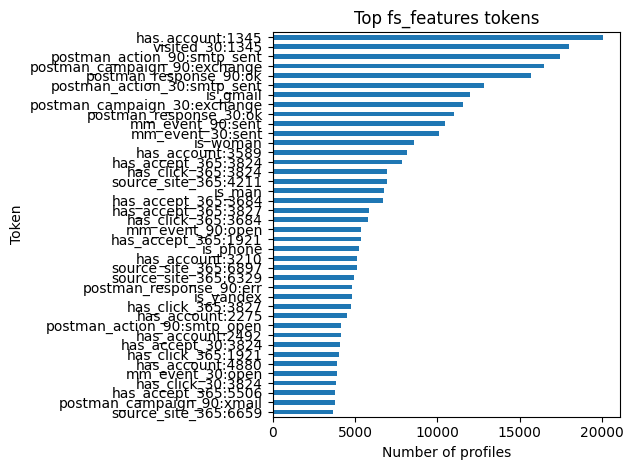

In [39]:
all_fs_tokens = Counter(token for tokens in profile_df["fs_tokens"] for token in tokens)
fs_token_freq = pd.DataFrame(all_fs_tokens.most_common(40), columns=["token", "n_profiles"])
display(fs_token_freq)

plt.figure(figsize=(10, 8))
fs_token_freq.sort_values("n_profiles").plot(x="token", y="n_profiles", kind="barh", legend=False)
plt.title("Top fs_features tokens")
plt.xlabel("Number of profiles")
plt.ylabel("Token")
plt.tight_layout()
plt.show()

In [40]:
fs_exploded = profile_df[["profile_id", "is_duplicate_entity", "fs_tokens"]].explode("fs_tokens").dropna(subset=["fs_tokens"])
fs_token_dup_rate = (
    fs_exploded.groupby("fs_tokens")
    .agg(
        n_profiles=("profile_id", "nunique"),
        duplicate_rate=("is_duplicate_entity", "mean"),
    )
    .query("n_profiles >= 100")
    .sort_values("duplicate_rate", ascending=False)
)

display(fs_token_dup_rate.head(30).style.format({"duplicate_rate": "{:.2%}"}))

,n_profiles,duplicate_rate
fs_tokens,,
has_accept_30:6366,119,87.39%
has_click_30:6366,113,84.96%
has_click_365:6878,121,81.82%
source_site_30:4880,606,81.52%
has_accept_365:6366,240,81.25%
has_click_365:6366,242,80.58%
has_click_365:6514,180,78.33%
has_order_30:4880,751,77.36%
has_accept_30:6514,114,77.19%


### Findings

- Some behavioral tokens have a noticeably elevated duplicate rate, so they are useful as duplicate-risk features and as part of pairwise similarity.
- Useful model features include Jaccard similarity over `fs_features`, the number of shared tokens, matching source-site tokens, and order/click/account flags.

## 19. Pairwise EDA: Positive Pairs vs. Negative Pairs

The matching model receives a **pair of profiles**, so profile pairs must be compared:

- positive pair: both `profile_id` values have the same `entity_id`;
- negative pair: the `profile_id` values have different `entity_id` values.

All positive pairs and a random sample of equally many negative pairs are generated below.

In [41]:
def make_positive_pairs(profile_df, max_pairs_per_entity=None):
    pairs = []
    for entity_id, group in profile_df.groupby("entity_id"):
        ids = group["profile_id"].tolist()
        if len(ids) < 2:
            continue
        combs = list(combinations(ids, 2))
        if max_pairs_per_entity is not None and len(combs) > max_pairs_per_entity:
            idx = rng.choice(len(combs), size=max_pairs_per_entity, replace=False)
            combs = [combs[i] for i in idx]
        for a, b in combs:
            if a > b:
                a, b = b, a
            pairs.append((a, b, 1))
    return pd.DataFrame(pairs, columns=["profile_id_1", "profile_id_2", "label"])


def make_negative_pairs(profile_df, n_pairs, random_state=42):
    rng_local = np.random.default_rng(random_state)
    ids = profile_df["profile_id"].to_numpy()
    entity_map = profile_df.set_index("profile_id")["entity_id"].to_dict()
    seen = set()
    pairs = []
    attempts = 0
    max_attempts = n_pairs * 100
    while len(pairs) < n_pairs and attempts < max_attempts:
        a, b = rng_local.choice(ids, size=2, replace=False)
        if a > b:
            a, b = b, a
        key = (a, b)
        if key in seen:
            attempts += 1
            continue
        if entity_map[a] == entity_map[b]:
            attempts += 1
            continue
        seen.add(key)
        pairs.append((a, b, 0))
        attempts += 1
    return pd.DataFrame(pairs, columns=["profile_id_1", "profile_id_2", "label"])

positive_pairs = make_positive_pairs(profile_df)
negative_pairs = make_negative_pairs(profile_df, n_pairs=len(positive_pairs), random_state=RANDOM_STATE)

pairs_df = pd.concat([positive_pairs, negative_pairs], ignore_index=True)
pairs_df = pairs_df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print(f"Positive pairs: {len(positive_pairs):,}")
print(f"Negative sampled pairs: {len(negative_pairs):,}")
print(f"Total pairwise EDA sample: {len(pairs_df):,}")
display(pairs_df.head())

Positive pairs: 16,363
Negative sampled pairs: 16,363
Total pairwise EDA sample: 32,726


,profile_id_1,profile_id_2,label
0,14d24574-2ff7-39c5-bbdb-bc01620ccb27,77a3f482-d051-3b93-8844-81932423cdf4,1
1,0c368448-4a4b-3470-9ea3-672326006933,aff07e25-688c-3e22-880d-bb3e593777ab,1
2,51a3d60d-586c-30f9-bbec-70c8fb52036c,fc5ecf7f-885e-3455-9d34-0e0fba091594,0
3,7acfa962-55d7-38b7-bc22-1a88f2e15ce0,d2ce5af4-883f-3a62-b906-c7d2102c7cb8,0
4,31811c40-8971-39a6-b703-e3b3f5af4a49,7e54878b-d309-3f67-9063-473a9d30e8a4,1


## 20. Pairwise Similarity Features

In [42]:
def seq_similarity(a, b):
    if pd.isna(a) or pd.isna(b):
        return np.nan
    return SequenceMatcher(None, str(a), str(b)).ratio()


def jaccard(a, b):
    sa = set(listify(a))
    sb = set(listify(b))
    if len(sa) == 0 and len(sb) == 0:
        return np.nan
    union = sa | sb
    if len(union) == 0:
        return np.nan
    return len(sa & sb) / len(union)


def both_present_equal(s1, s2):
    return s1.notna() & s2.notna() & (s1 == s2)


def both_present(s1, s2):
    return s1.notna() & s2.notna()

profile_cols_for_pairs = [
    "profile_id", "entity_id", "first_seen_at", "first_name_norm", "last_name_norm",
    "email_local", "email_domain", "phone_norm", "birth_year", "sex_norm",
    "identity_completeness_score", "np_tokens", "fs_tokens",
    "np_device", "np_browser", "np_osfamily", "np_geoname_id", "np_region_iso",
]

for c in ["rt_country", "rt_geoname", "rt_geoid", "rt_tz_offset", "rt_local_hour", "rt_day", "rt_population"]:
    if c in profile_df.columns and c not in profile_cols_for_pairs:
        profile_cols_for_pairs.append(c)

left = profile_df[profile_cols_for_pairs].add_suffix("_1")
right = profile_df[profile_cols_for_pairs].add_suffix("_2")

pair_features = (
    pairs_df
    .merge(left, left_on="profile_id_1", right_on="profile_id_1", how="left")
    .merge(right, left_on="profile_id_2", right_on="profile_id_2", how="left")
)

pair_features["same_phone"] = both_present_equal(pair_features["phone_norm_1"], pair_features["phone_norm_2"])
pair_features["phone_both_present"] = both_present(pair_features["phone_norm_1"], pair_features["phone_norm_2"])
pair_features["same_first_name"] = both_present_equal(pair_features["first_name_norm_1"], pair_features["first_name_norm_2"])
pair_features["first_name_both_present"] = both_present(pair_features["first_name_norm_1"], pair_features["first_name_norm_2"])
pair_features["same_last_name"] = both_present_equal(pair_features["last_name_norm_1"], pair_features["last_name_norm_2"])
pair_features["last_name_both_present"] = both_present(pair_features["last_name_norm_1"], pair_features["last_name_norm_2"])
pair_features["same_email_domain"] = both_present_equal(pair_features["email_domain_1"], pair_features["email_domain_2"])
pair_features["same_birth_year"] = both_present_equal(pair_features["birth_year_1"], pair_features["birth_year_2"])
pair_features["birth_year_both_present"] = both_present(pair_features["birth_year_1"], pair_features["birth_year_2"])

known_sex_1 = pair_features["sex_norm_1"].notna() & ~pair_features["sex_norm_1"].isin(["unknown", "none", "nan"])
known_sex_2 = pair_features["sex_norm_2"].notna() & ~pair_features["sex_norm_2"].isin(["unknown", "none", "nan"])
pair_features["same_known_sex"] = known_sex_1 & known_sex_2 & (pair_features["sex_norm_1"] == pair_features["sex_norm_2"])
pair_features["known_sex_conflict"] = known_sex_1 & known_sex_2 & (pair_features["sex_norm_1"] != pair_features["sex_norm_2"])
pair_features["both_sex_unknown"] = pair_features["sex_norm_1"].isin(["unknown", "none", "nan"]) & pair_features["sex_norm_2"].isin(["unknown", "none", "nan"])

for base_col in ["np_device", "np_browser", "np_osfamily", "np_geoname_id", "np_region_iso", "rt_country", "rt_geoname", "rt_geoid"]:
    c1 = f"{base_col}_1"
    c2 = f"{base_col}_2"
    if c1 in pair_features.columns and c2 in pair_features.columns:
        pair_features[f"same_{base_col}"] = both_present_equal(pair_features[c1], pair_features[c2])

pair_features["first_name_similarity"] = [seq_similarity(a, b) for a, b in zip(pair_features["first_name_norm_1"], pair_features["first_name_norm_2"])]
pair_features["last_name_similarity"] = [seq_similarity(a, b) for a, b in zip(pair_features["last_name_norm_1"], pair_features["last_name_norm_2"])]
pair_features["email_local_similarity"] = [seq_similarity(a, b) for a, b in zip(pair_features["email_local_1"], pair_features["email_local_2"])]

pair_features["np_tokens_jaccard"] = [jaccard(a, b) for a, b in zip(pair_features["np_tokens_1"], pair_features["np_tokens_2"])]
pair_features["fs_tokens_jaccard"] = [jaccard(a, b) for a, b in zip(pair_features["fs_tokens_1"], pair_features["fs_tokens_2"])]

pair_features["created_at_diff_days"] = (
    pair_features["first_seen_at_1"] - pair_features["first_seen_at_2"]
).abs().dt.total_seconds() / 86400

pair_features["created_within_1_hour"] = pair_features["created_at_diff_days"] <= (1 / 24)
pair_features["created_within_1_day"] = pair_features["created_at_diff_days"] <= 1
pair_features["created_within_7_days"] = pair_features["created_at_diff_days"] <= 7

pair_features["min_completeness"] = pair_features[["identity_completeness_score_1", "identity_completeness_score_2"]].min(axis=1)
pair_features["max_completeness"] = pair_features[["identity_completeness_score_1", "identity_completeness_score_2"]].max(axis=1)
pair_features["both_sparse_profiles"] = (pair_features["identity_completeness_score_1"] <= 2) & (pair_features["identity_completeness_score_2"] <= 2)

print(pair_features.shape)
display(pair_features.head())

(32726, 83)


,profile_id_1,profile_id_2,label,entity_id_1,first_seen_at_1,first_name_norm_1,last_name_norm_1,email_local_1,email_domain_1,phone_norm_1,birth_year_1,sex_norm_1,identity_completeness_score_1,np_tokens_1,fs_tokens_1,np_device_1,np_browser_1,np_osfamily_1,np_geoname_id_1,np_region_iso_1,rt_country_1,rt_geoname_1,rt_geoid_1,rt_tz_offset_1,rt_local_hour_1,rt_day_1,rt_population_1,entity_id_2,first_seen_at_2,first_name_norm_2,last_name_norm_2,email_local_2,email_domain_2,phone_norm_2,birth_year_2,sex_norm_2,identity_completeness_score_2,np_tokens_2,fs_tokens_2,np_device_2,np_browser_2,np_osfamily_2,np_geoname_id_2,np_region_iso_2,rt_country_2,rt_geoname_2,rt_geoid_2,rt_tz_offset_2,rt_local_hour_2,rt_day_2,rt_population_2,same_phone,phone_both_present,same_first_name,first_name_both_present,same_last_name,last_name_both_present,same_email_domain,same_birth_year,birth_year_both_present,same_known_sex,known_sex_conflict,both_sex_unknown,same_np_device,same_np_browser,same_np_osfamily,same_np_geoname_id,same_np_region_iso,same_rt_country,same_rt_geoname,same_rt_geoid,first_name_similarity,last_name_similarity,email_local_similarity,np_tokens_jaccard,fs_tokens_jaccard,created_at_diff_days,created_within_1_hour,created_within_1_day,created_within_7_days,min_completeness,max_completeness,both_sparse_profiles
0,14d24574-2ff7-39c5-bbdb-bc01620ccb27,77a3f482-d051-3b93-8844-81932423cdf4,1,b2493335d32f352fc7ec47c571a07324ecfcd40eacd49092322ece696633f804,2026-03-02 15:28:02.013,NaN,NaN,a.uyfomdncag,nw-sp.ru,NaN,NaN,unknown,1,"[browser:firefox, device:pc, osfamily:linux]","[has_accept_30:6366, has_accept_365:3265, has_accept_365:5358, has_accept_365:6366, has_account:1345, has_account:1696, has_account:1813, has_account:2054, ...",pc,firefox,linux,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,b2493335d32f352fc7ec47c571a07324ecfcd40eacd49092322ece696633f804,2026-03-04 17:30:33.003,NaN,NaN,zepyh,nw-sp.ru,NaN,NaN,unknown,1,"[browser:firefox, device:pc, osfamily:linux]","[has_accept_30:6366, has_accept_365:3265, has_accept_365:5358, has_accept_365:6366, has_account:1345, has_account:1696, has_account:1813, has_account:2054, ...",pc,firefox,linux,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False,False,True,False,False,False,False,True,True,True,True,False,False,False,False,False,NaN,NaN,0.117647,1.000000,0.966102,2.085081,False,False,True,1,1,True
1,0c368448-4a4b-3470-9ea3-672326006933,aff07e25-688c-3e22-880d-bb3e593777ab,1,597da83697a05acc9abfed7ae97fdfe939d71581d1c255ce2a320e0e7f8b628b,2025-11-19 11:29:29.948,NaN,NaN,anyyph.tuxjgxfd,mail.ru,NaN,NaN,unknown,1,"[browser:chrome, device:smartphone, geoname_id:625144, is_not_russia, osfamily:android, subdivision_1_iso_code:HM]","[visited_365:2865, visited_365:3265]",smartphone,chrome,android,625144,HM,BY,Minsk,625144.0,3.0,14.0,2.0,1742124.0,597da83697a05acc9abfed7ae97fdfe939d71581d1c255ce2a320e0e7f8b628b,2026-02-26 09:47:26.777,NaN,NaN,jajqahwgtfpsp879,gmail.com,NaN,NaN,unknown,1,"[browser:chrome, device:smartphone, geoname_id:625144, is_not_russia, osfamily:android, subdivision_1_iso_code:HM]","[has_accept_365:3322, has_account:1345, has_account:2891, has_click_365:3322, mm_event_30:sent, mm_event_90:sent, source_site_365:4211, visited_365:2865, vi...",smartphone,chrome,android,625144,HM,BY,Minsk,625144.0,3.0,12.0,3.0,1742124.0,False,False,False,False,False,False,False,False,False,False,False,True,True,True,True,True,True,True,True,True,NaN,NaN,0.129032,1.000000,0.222222,98.929130,False,False,False,1,1,True
2,51a3d60d-586c-30f9-bbec-70c8fb52036c,fc5ecf7f-885e-3455-9d34-0e0fba091594,0,3ae0d0b6cd664b54fdf06a85c50580c282c30c4bb78f5540c6ff5dafd5355ef0,2026-04-04 11:18:07.090,NaN,NaN,vyfw80684,gmail.com,NaN,NaN,unknown,1,"[browser:chrome, device:smartphone, geoname_id:581049, osfamily:android, subdivision_1_iso_code:ARK]","[has_accept_30:1921, has_accept_30:3684, has_accept_365:1921, has_accept_365:3684, has_accept_365:3824, has_account:1345, has_account:3210, has_click_30:192...",smartphone,chrome,

### Findings

- Strong positive signals include a normalized-phone match, high email local-part similarity, overlap among rare behavioral tokens, and matching geography or device without conflicts.
- Strong negative signals include different populated phone numbers, conflicting known sex values, clearly different dates of birth, and zero similarity across all available independent features.

## 20.1. Levenshtein and Fuzzy Similarity for Text Fields

This step adds dedicated similarity features for text fields.

Focus features:

- `email_local_lev_sim`: normalized Levenshtein similarity for the email local part;
- `email_local_token_sort_sim`: token-sort similarity for the email local part;
- `first_name_lev_sim`: Levenshtein similarity for the first name;
- `last_name_lev_sim`: Levenshtein similarity for the last name;
- `full_name_token_sort_sim`: token-sort similarity for the full name, when it can be constructed.

Interpretation: values closer to `1` indicate more similar strings. `NaN` means that at least one compared field is missing.

rapidfuzz available: True


,feature,pair_type,coverage,mean,median,p25,p75,n_non_null
0,email_local_lev_sim,negative,100.00%,0.080,0.077,0.000,0.125,16363
1,email_local_lev_sim,positive,100.00%,0.075,0.067,0.000,0.111,16363
2,email_local_token_sort_sim,negative,100.00%,0.168,0.167,0.105,0.222,16363
3,email_local_token_sort_sim,positive,100.00%,0.184,0.182,0.133,0.235,16363
4,first_name_lev_sim,negative,7.46%,0.183,0.143,0.000,0.250,1220
5,first_name_lev_sim,positive,3.78%,0.648,1.000,0.167,1.000,618
6,last_name_lev_sim,negative,0.04%,0.251,0.250,0.229,0.277,6
7,last_name_lev_sim,positive,0.06%,0.482,0.333,0.222,1.000,9
8,full_name_token_sort_sim,negative,7.46%,0.291,0.286,0.182,0.364,1220
9,full_name_token_sort_sim,positive,3.78%,0.661,1.000,0.308,1.000,618


,feature,auc,n_pairs_used,coverage
2,first_name_lev_sim,0.7726,1838,5.62%
4,full_name_token_sort_sim,0.7634,1838,5.62%
3,last_name_lev_sim,0.6204,15,0.05%
1,email_local_token_sort_sim,0.5559,32726,100.00%
0,email_local_lev_sim,0.4753,32726,100.00%


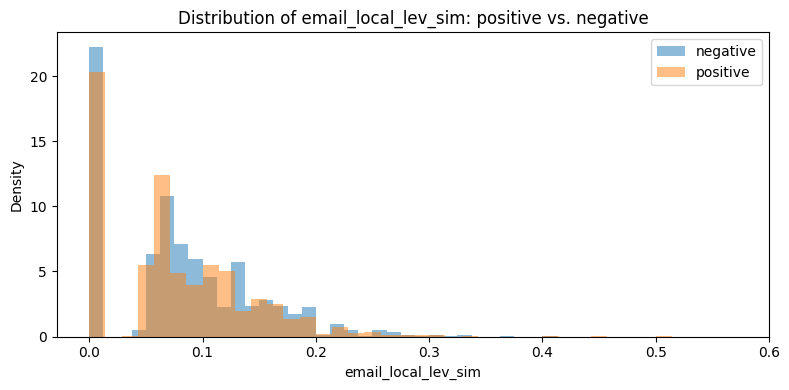

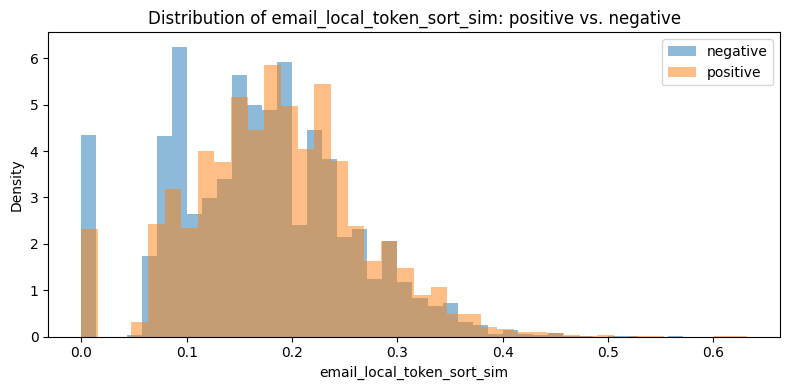

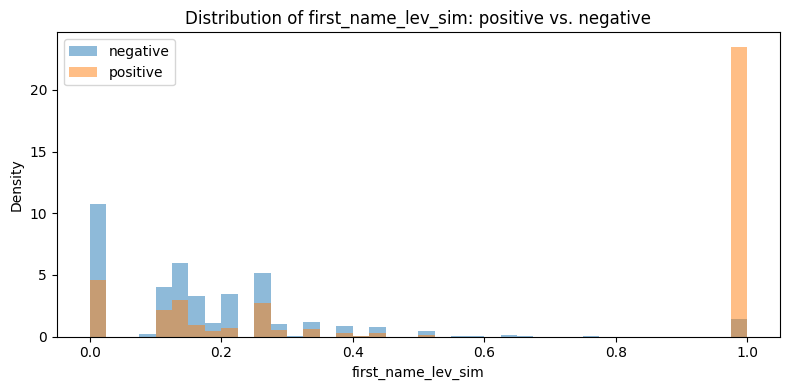

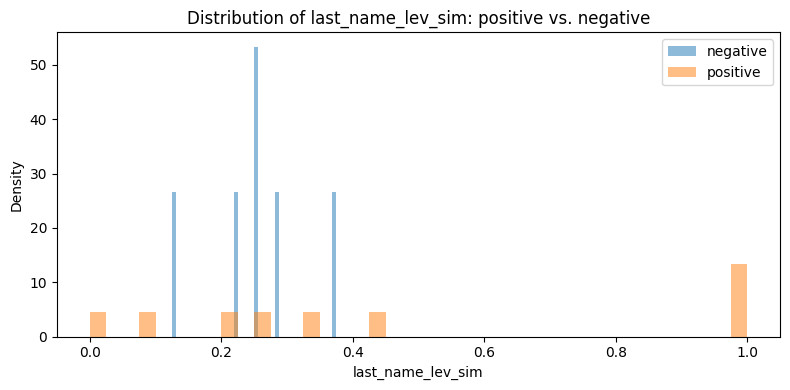

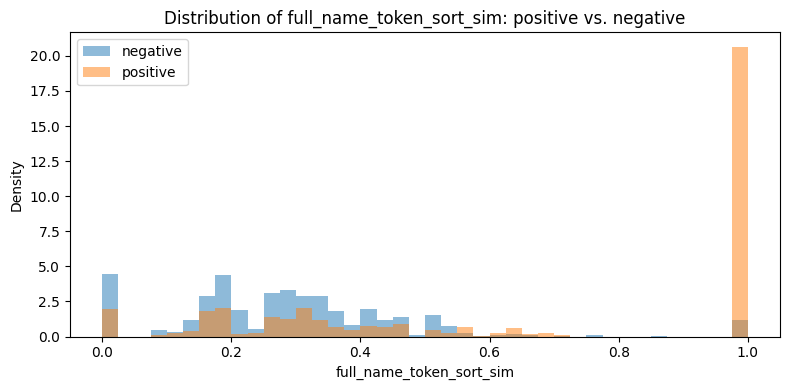

In [43]:
def normalize_for_fuzzy(x):
    """
    Normalizes a string for fuzzy comparison.
    Keeps letters and digits, converts to lowercase,
    collapses whitespace, and separates technical delimiters.
    """
    if pd.isna(x):
        return np.nan
    x = str(x).lower().strip()
    if x in ["", "none", "nan", "null", "unknown"]:
        return np.nan
    x = re.sub(r"[._\-]+", " ", x)
    x = re.sub(r"\s+", " ", x).strip()
    return x if x else np.nan


def normalize_email_local_for_lev(x):
    """
    More aggressive email local-part normalization for Levenshtein similarity:
    remove common delimiters so ivan.petrov and ivan_petrov
    are compared as ivanpetrov.
    """
    if pd.isna(x):
        return np.nan
    x = str(x).lower().strip()
    if x in ["", "none", "nan", "null", "unknown"]:
        return np.nan
    x = re.sub(r"[._\-]+", "", x)
    x = re.sub(r"\s+", "", x)
    return x if x else np.nan


try:
    from rapidfuzz.distance import Levenshtein as RFLevenshtein
    from rapidfuzz import fuzz as rffuzz
    HAS_RAPIDFUZZ = True
except ImportError:
    RFLevenshtein = None
    rffuzz = None
    HAS_RAPIDFUZZ = False


def levenshtein_distance_py(a, b):
    """
    Pure-Python fallback implementation of Levenshtein distance.
    Used only when rapidfuzz is not installed.
    """
    if a == b:
        return 0
    if len(a) < len(b):
        a, b = b, a
    if len(b) == 0:
        return len(a)

    previous_row = list(range(len(b) + 1))
    for i, ca in enumerate(a, start=1):
        current_row = [i]
        for j, cb in enumerate(b, start=1):
            insertions = previous_row[j] + 1
            deletions = current_row[j - 1] + 1
            substitutions = previous_row[j - 1] + (ca != cb)
            current_row.append(min(insertions, deletions, substitutions))
        previous_row = current_row
    return previous_row[-1]


def normalized_levenshtein_similarity(a, b):
    """
    Normalized Levenshtein similarity in the [0, 1] range.
    1.0 is an exact match; 0.0 is the maximum difference.
    """
    a = normalize_for_fuzzy(a)
    b = normalize_for_fuzzy(b)
    if pd.isna(a) or pd.isna(b):
        return np.nan

    if HAS_RAPIDFUZZ:
        return RFLevenshtein.normalized_similarity(a, b)

    max_len = max(len(a), len(b))
    if max_len == 0:
        return np.nan
    dist = levenshtein_distance_py(a, b)
    return 1 - dist / max_len


def normalized_email_local_levenshtein_similarity(a, b):
    a = normalize_email_local_for_lev(a)
    b = normalize_email_local_for_lev(b)
    if pd.isna(a) or pd.isna(b):
        return np.nan

    if HAS_RAPIDFUZZ:
        return RFLevenshtein.normalized_similarity(a, b)

    max_len = max(len(a), len(b))
    if max_len == 0:
        return np.nan
    dist = levenshtein_distance_py(a, b)
    return 1 - dist / max_len


def token_sort_similarity(a, b):
    """
    Token-sort similarity. Uses rapidfuzz's fast fuzz.token_sort_ratio when available.
    Otherwise falls back to SequenceMatcher over sorted tokens.
    """
    a = normalize_for_fuzzy(a)
    b = normalize_for_fuzzy(b)
    if pd.isna(a) or pd.isna(b):
        return np.nan

    if HAS_RAPIDFUZZ:
        return rffuzz.token_sort_ratio(a, b) / 100

    tokens_a = sorted(re.findall(r"[a-z\u0400-\u04ff0-9]+", a))
    tokens_b = sorted(re.findall(r"[a-z\u0400-\u04ff0-9]+", b))

    if not tokens_a or not tokens_b:
        return np.nan

    sorted_a = " ".join(tokens_a)
    sorted_b = " ".join(tokens_b)
    return SequenceMatcher(None, sorted_a, sorted_b).ratio()


print(f"rapidfuzz available: {HAS_RAPIDFUZZ}")


def make_full_name(first_name, last_name):
    parts = []
    for x in [first_name, last_name]:
        x = normalize_for_fuzzy(x)
        if not pd.isna(x):
            parts.append(x)
    return " ".join(parts) if parts else np.nan


pair_features["email_local_for_lev_1"] = pair_features["email_local_1"].map(normalize_email_local_for_lev)
pair_features["email_local_for_lev_2"] = pair_features["email_local_2"].map(normalize_email_local_for_lev)

pair_features["full_name_norm_1"] = [
    make_full_name(first, last)
    for first, last in zip(pair_features["first_name_norm_1"], pair_features["last_name_norm_1"])
]

pair_features["full_name_norm_2"] = [
    make_full_name(first, last)
    for first, last in zip(pair_features["first_name_norm_2"], pair_features["last_name_norm_2"])
]

pair_features["email_local_lev_sim"] = [
    normalized_email_local_levenshtein_similarity(a, b)
    for a, b in zip(pair_features["email_local_1"], pair_features["email_local_2"])
]

pair_features["email_local_token_sort_sim"] = [
    token_sort_similarity(a, b)
    for a, b in zip(pair_features["email_local_1"], pair_features["email_local_2"])
]

pair_features["first_name_lev_sim"] = [
    normalized_levenshtein_similarity(a, b)
    for a, b in zip(pair_features["first_name_norm_1"], pair_features["first_name_norm_2"])
]

pair_features["last_name_lev_sim"] = [
    normalized_levenshtein_similarity(a, b)
    for a, b in zip(pair_features["last_name_norm_1"], pair_features["last_name_norm_2"])
]

pair_features["full_name_token_sort_sim"] = [
    token_sort_similarity(a, b)
    for a, b in zip(pair_features["full_name_norm_1"], pair_features["full_name_norm_2"])
]

fuzzy_features = [
    "email_local_lev_sim",
    "email_local_token_sort_sim",
    "first_name_lev_sim",
    "last_name_lev_sim",
    "full_name_token_sort_sim",
]

fuzzy_summary_rows = []
for col in fuzzy_features:
    for label_value, label_name in [(0, "negative"), (1, "positive")]:
        data = pair_features.loc[pair_features["label"] == label_value, col]
        fuzzy_summary_rows.append({
            "feature": col,
            "pair_type": label_name,
            "coverage": data.notna().mean(),
            "mean": data.mean(skipna=True),
            "median": data.median(skipna=True),
            "p25": data.quantile(0.25),
            "p75": data.quantile(0.75),
            "n_non_null": data.notna().sum(),
        })

fuzzy_summary = pd.DataFrame(fuzzy_summary_rows)

display(
    fuzzy_summary.style.format({
        "coverage": "{:.2%}",
        "mean": "{:.3f}",
        "median": "{:.3f}",
        "p25": "{:.3f}",
        "p75": "{:.3f}",
    })
)

from sklearn.metrics import roc_auc_score

auc_rows = []
for col in fuzzy_features:
    temp = pair_features[["label", col]].dropna()
    if temp["label"].nunique() == 2 and len(temp) > 0:
        auc = roc_auc_score(temp["label"].astype(int), temp[col])
    else:
        auc = np.nan
    auc_rows.append({
        "feature": col,
        "auc": auc,
        "n_pairs_used": len(temp),
        "coverage": len(temp) / len(pair_features),
    })

fuzzy_auc = pd.DataFrame(auc_rows).sort_values("auc", ascending=False)

display(
    fuzzy_auc.style.format({
        "auc": "{:.4f}",
        "coverage": "{:.2%}",
    })
)

for col in fuzzy_features:
    plt.figure(figsize=(8, 4))
    for label_value, label_name in [(0, "negative"), (1, "positive")]:
        data = pair_features.loc[pair_features["label"] == label_value, col].dropna()
        if len(data) > 0:
            plt.hist(data, bins=40, alpha=0.5, density=True, label=label_name)
    plt.title(f"Distribution of {col}: positive vs. negative")
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.show()


### Key Findings

- The most practically useful target for fuzzy comparison is `email_local_norm`, because email is populated for every profile while each full email is unique.
- Fuzzy features for `first_name` and `last_name` have low coverage due to missing values, but can provide a strong supporting signal when both values are populated.

## 21. Comparing Features for Positive and Negative Pairs

In [44]:
bool_features = [
    c for c in pair_features.columns
    if c.startswith("same_") or c.endswith("_both_present") or c in [
        "phone_both_present", "same_known_sex", "known_sex_conflict", "both_sex_unknown",
        "created_within_1_hour", "created_within_1_day", "created_within_7_days", "both_sparse_profiles"
    ]
]

bool_summary = []
for col in bool_features:
    if pair_features[col].dtype == bool or set(pair_features[col].dropna().unique()).issubset({0, 1, True, False}):
        grp = pair_features.groupby("label")[col].mean()
        bool_summary.append({
            "feature": col,
            "negative_rate": grp.get(0, np.nan),
            "positive_rate": grp.get(1, np.nan),
            "lift_positive_vs_negative": (grp.get(1, np.nan) / grp.get(0, np.nan)) if grp.get(0, np.nan) not in [0, np.nan] else np.nan,
        })

bool_summary = pd.DataFrame(bool_summary).sort_values("positive_rate", ascending=False)
display(bool_summary.style.format({
    "negative_rate": "{:.2%}",
    "positive_rate": "{:.2%}",
    "lift_positive_vs_negative": "{:.2f}",
}))

,feature,negative_rate,positive_rate,lift_positive_vs_negative
14,same_np_osfamily,48.01%,95.59%,1.99
12,same_np_device,78.81%,95.56%,1.21
23,both_sparse_profiles,57.17%,85.23%,1.49
16,same_np_region_iso,1.28%,82.73%,64.77
17,same_rt_country,32.16%,82.48%,2.56
11,both_sex_unknown,51.97%,82.27%,1.58
13,same_np_browser,29.30%,80.11%,2.73
15,same_np_geoname_id,0.74%,78.62%,106.31
19,same_rt_geoid,0.73%,77.49%,105.66
18,same_rt_geoname,0.72%,77.46%,107.42


In [45]:
numeric_pair_features = [
    "first_name_similarity", "last_name_similarity", "email_local_similarity",
    "email_local_lev_sim", "email_local_token_sort_sim",
    "first_name_lev_sim", "last_name_lev_sim", "full_name_token_sort_sim",
    "np_tokens_jaccard", "fs_tokens_jaccard", "created_at_diff_days",
    "min_completeness", "max_completeness"
]

numeric_summary = (
    pair_features.groupby("label")[numeric_pair_features]
    .agg(["count", "mean", "median", "std"])
)

display(numeric_summary)

first_name_similarity                               last_name_similarity                               email_local_similarity                                \
                      count      mean    median       std                count      mean    median       std                  count      mean    median       std   
label                                                                                                                                                               
0                      1220  0.283609  0.266667  0.202621                    6  0.303663  0.296703  0.159194                  16363  0.155779  0.153846  0.080766   
1                       618  0.686341  1.000000  0.385021                    9  0.512698  0.333333  0.375391                  16363  0.163833  0.153846  0.080340   

      email_local_lev_sim                               email_local_token_sort_sim                               first_name_lev_sim                                \
                    count      mean    median       std                      count      mean    median       std              count      mean    median       std   
label                                                                                                                                                               
0                   16363  0.079764  0.076923  0.065710                      16363  0.168135  0.166667  0.083135               1220  0.182507  0.142857  0.200517   
1                   16363  0.074840  0.066667  0.063675                      16363  0.184286  0.181818  0.080740                618  0.647966  1.000000  0.427323   

      last_name_lev_sim                               full_name_token_sort_sim                               np_tokens_jaccard                               fs_tokens_jaccard  \
                  count      mean    median       std                    count      mean    median       std             count      mean    median       std             count   
label                                                                                                                                                                            
0                     6  0.251323  0.250000  0.081592                     1220  0.290875  0.285714  0.192543             16362  0.238410  0.222222  0.176053             13267   
1                     9  0.481570  0.333333  0.407658                      618  0.661492  1.000000  0.370257             16345  0.908296  1.000000  0.206269              6827   

                                    created_at_diff_days                                  min_completeness                            max_completeness                             
           mean    median       std                count       mean     median        std            count      mean median       std            count      mean median       std  
label                                                                                                                                                                              
0      0.022638  0.000000  0.056580                16363  59.020652  51.663143  41.879309            16363  1.190185    1.0  0.525836            16363  2.126322    2.0  1.075783  
1      0.471646  0.473684  0.377427                16363  16.378019   0.054902  31.728692            16363  1.089409    1.0  0.380604            16363  1.408299    1.0  0.822877

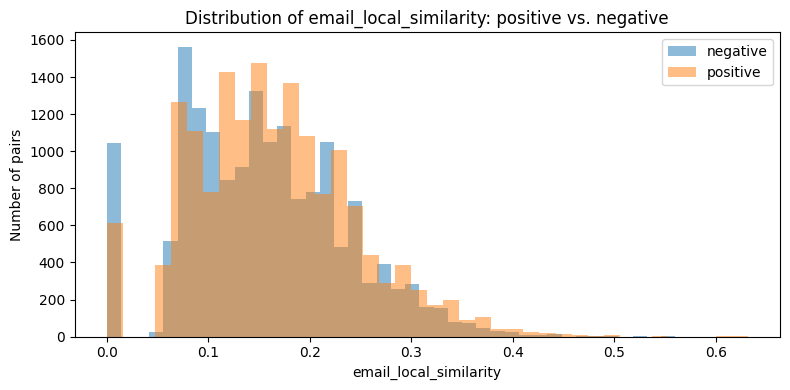

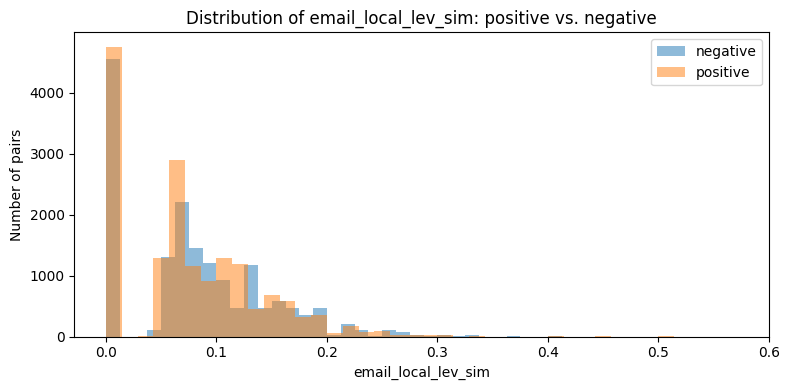

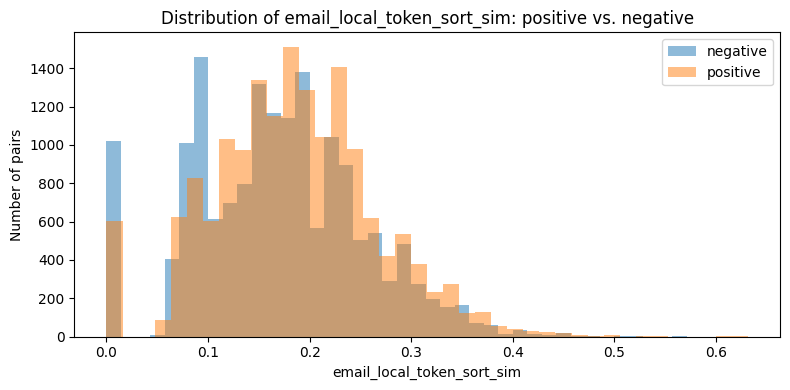

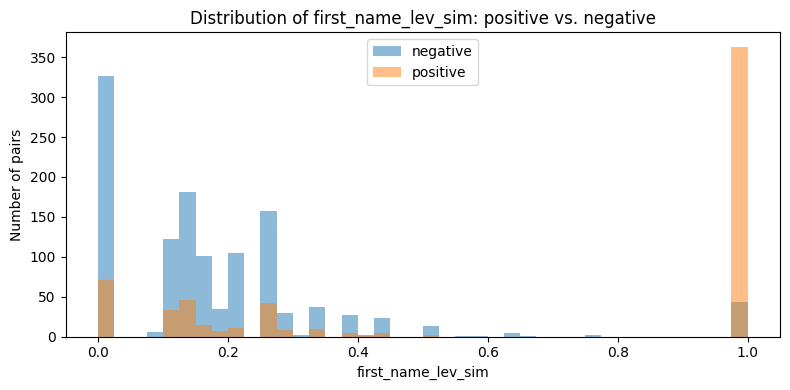

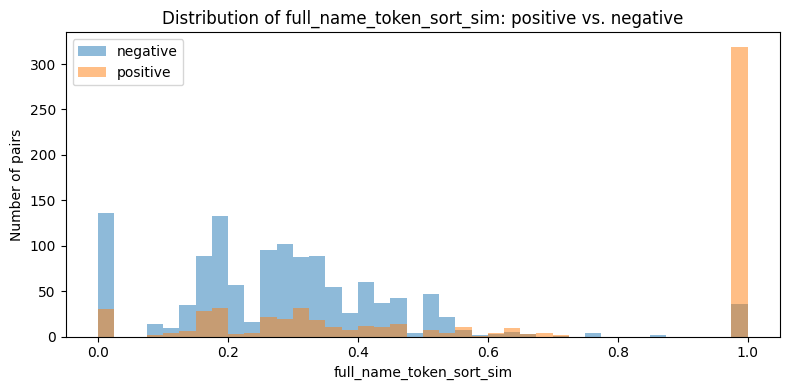

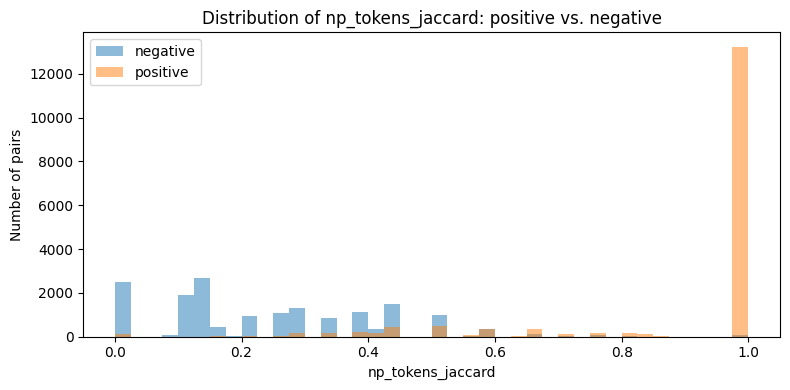

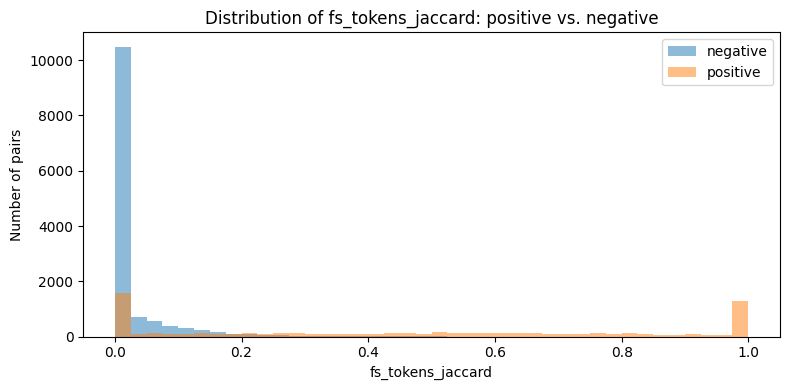

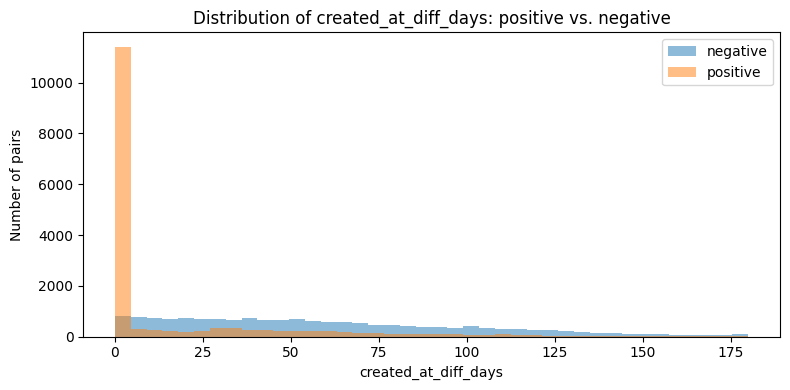

In [46]:
for col in [
    "email_local_similarity", "email_local_lev_sim", "email_local_token_sort_sim",
    "first_name_lev_sim", "full_name_token_sort_sim",
    "np_tokens_jaccard", "fs_tokens_jaccard", "created_at_diff_days"
]:
    plt.figure(figsize=(8, 4))
    for label_value, label_name in [(0, "negative"), (1, "positive")]:
        data = pair_features.loc[pair_features["label"] == label_value, col].dropna()
        if col == "created_at_diff_days":
            data = data.clip(upper=180)
        plt.hist(data, bins=40, alpha=0.5, label=label_name)
    plt.title(f"Distribution of {col}: positive vs. negative")
    plt.xlabel(col)
    plt.ylabel("Number of pairs")
    plt.legend()
    plt.tight_layout()
    plt.show()

### Findings

- Select features whose distributions differ noticeably between positive and negative pairs.
- A feature with a high mean or median for positive pairs and a low value for negative pairs is a strong candidate for the final comparison feature set.
- If the distributions nearly overlap, the feature is either weak or useful only in combination with other features.
- For features with many `NaN` values, analyze both similarity and coverage: a strong low-coverage feature remains useful as an additional signal.

## 22. Feature Engineering for Profile Comparison

This section defines pairwise features for comparing two customer profiles. Each row in `pair_features` represents a `profile_id_1` and `profile_id_2` pair, while the features describe similarity, differences, and the completeness of available information.

The features are divided into the following groups:

1. **Contact features**: phone and email features.
2. **Name features**: exact matches and fuzzy similarity for first name, last name, and full name.
3. **Demographic features**: birth year and sex, with explicit handling of `unknown`.
4. **Geographic features**: country, city/geoid, timezone, and regional tokens.
5. **Technical features**: device, browser, operating system, and technical tokens.
6. **Behavioral features**: overlap among `fs_features`.
7. **Temporal features**: distance between profile creation dates.
8. **Completeness features**: how complete both profiles are and whether they are sparse.

In [47]:
feature_catalog = pd.DataFrame([
    {
        "feature_group": "contact_phone",
        "feature_name": "same_phone",
        "source_fields": "phone_norm",
        "calculation_logic": "1 when both normalized phone numbers are populated and match",
        "interpretation": "A very strong positive signal with low coverage",
        "priority": "high",
    },
    {
        "feature_group": "contact_phone",
        "feature_name": "phone_both_present",
        "source_fields": "phone_norm",
        "calculation_logic": "1 when both profiles have a phone number",
        "interpretation": "Indicates whether phone comparison is applicable",
        "priority": "medium",
    },
    {
        "feature_group": "email",
        "feature_name": "same_email_domain",
        "source_fields": "email_domain",
        "calculation_logic": "1 when email domains match",
        "interpretation": "A weak-to-medium signal; common domains alone do not prove duplication",
        "priority": "medium",
    },
    {
        "feature_group": "email",
        "feature_name": "email_local_similarity",
        "source_fields": "email_local",
        "calculation_logic": "SequenceMatcher similarity between email local parts",
        "interpretation": "A key feature because email is almost always populated while exact addresses are unique",
        "priority": "high",
    },
    {
        "feature_group": "email",
        "feature_name": "email_local_lev_sim",
        "source_fields": "email_local_norm",
        "calculation_logic": "Normalized Levenshtein similarity between email local parts",
        "interpretation": "Captures typos and spelling variations in the email local part",
        "priority": "high",
    },
    {
        "feature_group": "email",
        "feature_name": "email_local_token_sort_sim",
        "source_fields": "email_local_norm",
        "calculation_logic": "Token-sort similarity for the email local part",
        "interpretation": "Useful when email components are reordered or use different separators",
        "priority": "medium",
    },
    {
        "feature_group": "name",
        "feature_name": "same_first_name",
        "source_fields": "first_name_norm",
        "calculation_logic": "1 when both normalized first names are populated and match",
        "interpretation": "A useful but incomplete signal because of the high missing-value rate",
        "priority": "medium",
    },
    {
        "feature_group": "name",
        "feature_name": "first_name_lev_sim",
        "source_fields": "first_name_norm",
        "calculation_logic": "Normalized Levenshtein similarity for the first name",
        "interpretation": "Captures first-name typos and transliteration variants",
        "priority": "medium",
    },
    {
        "feature_group": "name",
        "feature_name": "same_last_name",
        "source_fields": "last_name_norm",
        "calculation_logic": "1 when both normalized last names are populated and match",
        "interpretation": "Can be a strong signal, but coverage is low",
        "priority": "medium",
    },
    {
        "feature_group": "name",
        "feature_name": "last_name_lev_sim",
        "source_fields": "last_name_norm",
        "calculation_logic": "Normalized Levenshtein similarity for the last name",
        "interpretation": "An additional fuzzy signal when last name is populated",
        "priority": "medium",
    },
    {
        "feature_group": "name",
        "feature_name": "full_name_token_sort_sim",
        "source_fields": "first_name_norm + last_name_norm",
        "calculation_logic": "Token-sort similarity for the full name",
        "interpretation": "Useful when first and last names are reordered or partially populated",
        "priority": "medium",
    },
    {
        "feature_group": "demographic",
        "feature_name": "same_birth_year",
        "source_fields": "birth_year",
        "calculation_logic": "1 when both birth years are populated and match",
        "interpretation": "A strong supporting signal when available, but coverage is very low",
        "priority": "low",
    },
    {
        "feature_group": "demographic",
        "feature_name": "same_known_sex",
        "source_fields": "sex_norm",
        "calculation_logic": "1 when both profiles have the same known sex",
        "interpretation": "A weak-to-medium positive signal; unknown is not a meaningful match",
        "priority": "medium",
    },
    {
        "feature_group": "demographic",
        "feature_name": "known_sex_conflict",
        "source_fields": "sex_norm",
        "calculation_logic": "1 when both sex values are known and differ",
        "interpretation": "A negative signal indicating a potential identity conflict",
        "priority": "high",
    },
    {
        "feature_group": "geo",
        "feature_name": "same_rt_geoid / same_rt_geoname / same_rt_country",
        "source_fields": "realtime_features",
        "calculation_logic": "Comparison of parsed geographic fields",
        "interpretation": "Useful as supporting context; different people may share cities and countries",
        "priority": "medium",
    },
    {
        "feature_group": "technical",
        "feature_name": "same_np_device / same_np_browser / same_np_osfamily",
        "source_fields": "non_processing_features",
        "calculation_logic": "Comparison of extracted device, browser, and OS-family values",
        "interpretation": "Weak individual signals that help when combined with email, geography, and behavior",
        "priority": "medium",
    },
    {
        "feature_group": "technical",
        "feature_name": "np_tokens_jaccard",
        "source_fields": "non_processing_features",
        "calculation_logic": "Jaccard similarity between technical-token sets",
        "interpretation": "Measures technical profile similarity across device, browser, OS, and regional tokens",
        "priority": "high",
    },
    {
        "feature_group": "behavioral",
        "feature_name": "fs_tokens_jaccard",
        "source_fields": "fs_features",
        "calculation_logic": "Jaccard similarity between behavioral and marketplace token sets",
        "interpretation": "A key feature for sparse profiles with little personal data",
        "priority": "high",
    },
    {
        "feature_group": "temporal",
        "feature_name": "created_at_diff_days",
        "source_fields": "first_seen_at",
        "calculation_logic": "Absolute difference in days between profile first-seen dates",
        "interpretation": "Helps distinguish nearly simultaneous registrations from profiles created far apart",
        "priority": "medium",
    },
    {
        "feature_group": "temporal",
        "feature_name": "created_within_1_hour / 1_day / 7_days",
        "source_fields": "first_seen_at",
        "calculation_logic": "Flags indicating proximity of profile creation dates",
        "interpretation": "Useful for detecting repeated or technical duplicate-creation patterns",
        "priority": "medium",
    },
    {
        "feature_group": "completeness",
        "feature_name": "min_completeness / max_completeness / both_sparse_profiles",
        "source_fields": "identity_completeness_score",
        "calculation_logic": "Comparison of identity-field completeness across two profiles",
        "interpretation": "Indicates comparison reliability; sparse pairs require careful interpretation",
        "priority": "high",
    },
])

pd.set_option("display.max_colwidth", 140)
display(feature_catalog)


,feature_group,feature_name,source_fields,calculation_logic,interpretation,priority
0,contact_phone,same_phone,phone_norm,1 when both normalized phone numbers are populated and match,A very strong positive signal with low coverage,high
1,contact_phone,phone_both_present,phone_norm,1 when both profiles have a phone number,Indicates whether phone comparison is applicable,medium
2,email,same_email_domain,email_domain,1 when email domains match,A weak-to-medium signal; common domains alone do not prove duplication,medium
3,email,email_local_similarity,email_local,SequenceMatcher similarity between email local parts,A key feature because email is almost always populated while exact addresses are unique,high
4,email,email_local_lev_sim,email_local_norm,Normalized Levenshtein similarity between email local parts,Captures typos and spelling variations in the email local part,high
5,email,email_local_token_sort_sim,email_local_norm,Token-sort similarity for the email local part,Useful when email components are reordered or use different separators,medium
6,name,same_first_name,first_name_norm,1 when both normalized first names are populated and match,A useful but incomplete signal because of the high missing-value rate,medium
7,name,first_name_lev_sim,first_name_norm,Normalized Levenshtein similarity for the first name,Captures first-name typos and transliteration variants,medium
8,name,same_last_name,last_name_norm,1 when both normalized last names are populated and match,"Can be a strong signal, but coverage is low",medium
9,name,last_name_lev_sim,last_name_norm,Normalized Levenshtein similarity for the last name,An additional fuzzy signal when last name is populated,medium


In [48]:
catalog_feature_names = []
for value in feature_catalog["feature_name"]:
    for part in str(value).replace(" / ", "|").split("|"):
        catalog_feature_names.append(part.strip())

available_catalog_features = sorted([f for f in catalog_feature_names if f in pair_features.columns])
missing_catalog_features = sorted([f for f in catalog_feature_names if f not in pair_features.columns])

print("Catalog features already available in pair_features:")
print(available_catalog_features)

print("\nCatalog features that are conceptual or require further implementation:")
print(missing_catalog_features)

feature_diagnostics = []
for col in pair_features.columns:
    if col in ["profile_id_1", "profile_id_2", "entity_id_1", "entity_id_2", "label"]:
        continue
    if pair_features[col].dtype == "object":
        continue

    temp = pair_features[["label", col]].copy()
    coverage = temp[col].notna().mean()

    neg_mean = temp.loc[temp["label"] == 0, col].mean()
    pos_mean = temp.loc[temp["label"] == 1, col].mean()

    abs_diff = np.nan
    if pd.notna(pos_mean) and pd.notna(neg_mean):
        diff = pos_mean - neg_mean
        if isinstance(diff, pd.Timedelta):
            abs_diff = abs(diff).total_seconds()
        elif pd.api.types.is_numeric_dtype(diff):
            abs_diff = abs(diff)
        else:
            abs_diff = np.nan

    feature_diagnostics.append({
        "feature": col,
        "coverage": coverage,
        "negative_mean": neg_mean,
        "positive_mean": pos_mean,
        "abs_mean_diff": abs_diff,
    })

feature_diagnostics = (
    pd.DataFrame(feature_diagnostics)
    .sort_values(["abs_mean_diff", "coverage"], ascending=False)
)

display(feature_diagnostics.head(30).style.format({
    "coverage": "{:.2%}",
    "negative_mean": "{:.4f}",
    "positive_mean": "{:.4f}",
    "abs_mean_diff": "{:.4f}",
}))

Catalog features already available in pair_features:
['both_sparse_profiles', 'created_at_diff_days', 'created_within_1_hour', 'email_local_lev_sim', 'email_local_similarity', 'email_local_token_sort_sim', 'first_name_lev_sim', 'fs_tokens_jaccard', 'full_name_token_sort_sim', 'known_sex_conflict', 'last_name_lev_sim', 'max_completeness', 'min_completeness', 'np_tokens_jaccard', 'phone_both_present', 'same_birth_year', 'same_email_domain', 'same_first_name', 'same_known_sex', 'same_last_name', 'same_np_browser', 'same_np_device', 'same_np_osfamily', 'same_phone', 'same_rt_country', 'same_rt_geoid', 'same_rt_geoname']

Catalog features that are conceptual or require further implementation:
['1_day', '7_days']


,feature,coverage,negative_mean,positive_mean,abs_mean_diff
8,first_seen_at_2,100.00%,.4f,.4f,2650140.7067
0,first_seen_at_1,100.00%,.4f,.4f,2620453.5588
3,rt_geoid_1,84.66%,1135482.0635,795502.9746,339979.0890
11,rt_geoid_2,84.66%,1132961.9056,793346.4892,339615.4163
7,rt_population_1,84.61%,1224155.9124,888330.9449,335824.9675
15,rt_population_2,84.63%,1185277.5470,891875.9687,293401.5782
41,created_at_diff_days,100.00%,59.0207,16.3780,42.6426
1,birth_year_1,0.39%,1976.1957,1978.1714,1.9758
32,same_np_region_iso,100.00%,0.0128,0.8273,0.8145
31,same_np_geoname_id,100.00%,0.0074,0.7862,0.7788


### Findings

- Profile comparison requires a set of signals rather than one universal feature: contact, fuzzy text, demographic, geographic, technical, behavioral, temporal, and completeness features.
- The most promising features for this dataset are `email_local_lev_sim`, `email_local_similarity`, `fs_tokens_jaccard`, `np_tokens_jaccard`, `same_phone`, `same_first_name`, `known_sex_conflict`, `created_at_diff_days`, and profile-completeness flags.
- `phone` is a strong match signal but does not cover most profiles, so it should be an additional identifier rather than the sole comparison basis.
- `email` should be represented by derived features: local-part similarity, Levenshtein similarity, token-sort similarity, domain, and normalized local-part variants. Exact matching on the full email address does not solve duplicate detection in this dataset.
- Coverage must be considered separately for `sex`, `birthday`, `first_name`, and `last_name`. A missing value is not a negative signal; it represents uncertainty.
- `fs_features` and `non_processing_features` are especially important for sparse profiles with missing or partial classic personal fields.

## 23. Main EDA Conclusions

1. **The main unit of analysis is `profile_id`, not the source row.** A profile may appear multiple times in the source file, so rows must be aggregated into a profile-level table before duplicate analysis.

2. **`entity_id` serves as the ground-truth cluster.** If one `entity_id` contains multiple `profile_id` values, those profiles form a labeled duplicate group.

3. **The data contains a substantial share of duplicate profiles.** After aggregation, some `entity_id` values contain more than one `profile_id`; these groups form the positive examples for pairwise EDA.

4. **Classic identity fields are highly sparse.** `birthday`, `last_name`, `phone`, and `first_name` have high missing-value rates. They are useful but cannot be the sole basis for profile comparison.

5. **Email is populated for almost every profile, but exact matching on the full email address is ineffective.** Its main value lies in derived features: local-part similarity, Levenshtein similarity, token-sort similarity, domain, digit presence, and structural local-part patterns.

6. **Phone is a high-precision, low-coverage signal.** A normalized-phone match strongly supports duplication, but missing phone numbers for most profiles require additional similarity sources.

7. **Name and date of birth must be used carefully.** Matching names or birth years can increase confidence, but missing values and spelling variations require fuzzy comparison and presence flags.

8. **Technical and behavioral features are critical for sparse profiles.** `non_processing_features`, `realtime_features`, and `fs_features` provide additional signals when name, phone, and date of birth are missing.

9. **Pairwise EDA is central to entity resolution.** The task requires comparing profile pairs: positive pairs share an `entity_id`, while negative pairs have different `entity_id` values.

10. **Levenshtein and fuzzy similarity make an important contribution to duplicate-detection features.** This is especially true for `email_local`, as well as `first_name`, `last_name`, and `full_name` when populated. Their usefulness should be evaluated through positive/negative pair distributions and AUC.

# Model Development

In [69]:
import pandas as pd
import numpy as np
import networkx as nx

import random
from itertools import combinations
from difflib import SequenceMatcher

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    adjusted_rand_score,
    classification_report,
    f1_score,
    normalized_mutual_info_score,
    precision_score,
    recall_score,
)

from catboost import CatBoostClassifier

### Loading the Dataset

In [70]:
df = pd.read_parquet("profile_level_dataset_parquet.parquet")

### Preparing Data for the Model

In [71]:
data = df.copy()

data["name_clean"] = (
    data["first_name_norm"].fillna("").astype(str) + " " +
    data["last_name_norm"].fillna("").astype(str)
).str.lower().str.strip()

data["email_local_clean"] = data["email_local"].fillna("").astype(str).str.lower().str.strip()
data["email_domain_clean"] = data["email_domain"].fillna("").astype(str).str.lower().str.strip()

data["phone_clean"] = (
    data["phone_norm"]
    .fillna("")
    .astype(str)
    .str.replace(r"\D", "", regex=True)
)

data["birth_clean"] = data["birth_year"]

data["sex_clean"] = data["sex_norm"].fillna("unknown").astype(str).str.lower().str.strip()

data["city_clean"] = data["rt_geoname"].fillna("").astype(str).str.lower().str.strip()

data["device_clean"] = data["np_device"].fillna("").astype(str).str.lower().str.strip()
data["browser_clean"] = data["np_browser"].fillna("").astype(str).str.lower().str.strip()
data["os_clean"] = data["np_osfamily"].fillna("").astype(str).str.lower().str.strip()
data["region_clean"] = data["np_region_iso"].fillna("").astype(str).str.lower().str.strip()

data["np_tokens_clean"] = data["np_tokens"].fillna("").astype(str).str.lower()
data["fs_tokens_clean"] = data["fs_tokens"].fillna("").astype(str).str.lower()
data["realtime_features_clean"] = data["realtime_features"].fillna("").astype(str).str.lower()

data["rt_visit_count_clean"] = pd.to_numeric(
    data["rt_visit_count"],
    errors="coerce"
).fillna(0)
data["profile_lifetime_days_clean"] = pd.to_numeric(
    data["profile_lifetime_days"],
    errors="coerce"
).fillna(0)

print(data[[
    "profile_id", "entity_id",
    "name_clean", "email_local_clean", "email_domain_clean",
    "phone_clean", "birth_clean", "sex_clean",
    "city_clean", "device_clean", "browser_clean", "os_clean", "region_clean",
    "np_tokens_clean", "fs_tokens_clean", "realtime_features_clean", "rt_visit_count_clean", "profile_lifetime_days_clean"
]].head())

                             profile_id                                                         entity_id name_clean email_local_clean email_domain_clean  phone_clean  \
0  000163e0-b9b4-3323-84ea-6495df7fe895  266eb686284a35db45a797ef75c01fc276e71fee1eb2aaaf71d3606a64b91aeb                srnxztxqa8004          gmail.com                
1  0001ced1-cecc-3dc9-b4c1-acf162c8b2b5  ef07a5be121a62611f6b1f7e25fed25a0d02b9571d7bbcfb0370ff164dd1bbd4                      wjpfhmp             vk.com  79959678942   
2  0002ac9a-fd3f-31a7-9ab5-77b1d3961382  244363f995686f034394129500ab9c06fa262eefa04cfc1c3bb554f1227f2f9c   василиса     qleopvd052996          gmail.com                
3  00036d8f-9320-39b0-96e9-f0a457fc82a4  5b3e5b68690777e70e9f394d45ebb85aeb5f12c68b2f0656e2ca6358a8a01eb8                  hxubxrhcy67           inbox.ru                
4  0003e46e-fc6c-34a8-8358-606d66c1eec2  eb99135fb3e4af6723c6daf1ac22f4f9c15218c3f17a5324daef53e70032a8da             lxhsidqbzwloh588          gmail.

The data was converted to a consistent format: text features were cleaned and lowercased, email was split into local part and domain, and phone numbers were normalized to digit sequences.

Jaccard similarity was used for behavioral features (`np_tokens`, `fs_tokens`, and `realtime_features`), and numeric difference features were added, including visit count and profile lifetime.

As a result, each profile is represented by a feature set suitable for pairwise comparison.

In [72]:
required_cols = ["profile_id", "entity_id", "email"]

missing = [c for c in required_cols if c not in data.columns]
assert not missing, f"Missing required columns: {missing}"

print("Unique profile_id values:", df["profile_id"].nunique())
print("Unique entity_id values:", df["entity_id"].nunique())

Unique profile_id values: 61927
Unique entity_id values: 53369


The dataset therefore contains approximately 13.8% duplicate profiles. The same ratio is assumed for real-world data when constructing the corresponding imbalance in the training and test datasets.

Split the data into training, validation, and test datasets.  
The split is performed by `entity_id` to prevent data leakage: profiles belonging to the same user cannot appear in both training and validation/test data.

In [73]:
entities = data['entity_id'].unique()

train_entities, temp_entities = train_test_split(entities, test_size=0.3, random_state=42)
val_entities, test_entities = train_test_split(temp_entities, test_size=0.5, random_state=42)

train_df = data[data['entity_id'].isin(train_entities)]
val_df = data[data['entity_id'].isin(val_entities)]
test_df = data[data['entity_id'].isin(test_entities)]

print(len(train_df), len(val_df), len(test_df))

43449 9266 9212


### Pair Generation

The task is formulated as binary classification of profile pairs. Positive pairs contain profiles with the same `entity_id`; negative pairs contain profiles with different `entity_id` values.

Positive Pairs

In [74]:
def generate_positive_pairs(df):
    pairs = []
    
    grouped = df.groupby('entity_id')
    
    for _, group in grouped:
        ids = group['profile_id'].values
        
        if len(ids) > 1:
            for a, b in combinations(ids, 2):
                pairs.append((a, b, 1))
    
    return pd.DataFrame(pairs, columns=['id1', 'id2', 'target'])

Negative Pairs

In [75]:
def generate_negative_pairs(df, n_samples=10000):
    pairs = []
    
    ids = df[['profile_id', 'entity_id']].values
    
    while len(pairs) < n_samples:
        a, b = random.sample(list(ids), 2)
        
        if a[1] != b[1]:  # different entities
            pairs.append((a[0], b[0], 0))
    
    return pd.DataFrame(pairs, columns=['id1', 'id2', 'target'])

#### Building Training Pairs

The source data has a relatively low duplicate rate, but pair generation creates a strong imbalance because most pairs are not duplicates. Imbalanced samples were considered to make training conditions closer to real-world conditions.

In [76]:
pos_pairs = generate_positive_pairs(train_df)
neg_pairs = generate_negative_pairs(train_df, n_samples=len(pos_pairs) * 7)

pairs_df = pd.concat([pos_pairs, neg_pairs]).sample(frac=1).reset_index(drop=True)

print(pairs_df.shape)

(110384, 3)


### Feature engineering

In [77]:
df_indexed = data.set_index('profile_id')

#### Feature Generation

In [78]:
def sim(a, b):
    if pd.isna(a) or pd.isna(b):
        return 0
    
    a = str(a)
    b = str(b)
    
    if a == "" or b == "":
        return 0
    
    return SequenceMatcher(None, a, b).ratio()


def exact_match(a, b):
    if pd.isna(a) or pd.isna(b):
        return 0
    
    a = str(a)
    b = str(b)
    
    if a == "" or b == "":
        return 0
    
    return int(a == b)


def to_token_set(x):
    if pd.isna(x):
        return set()
    
    x = str(x).lower()
    
    for ch in "[]{}()',\"":
        x = x.replace(ch, " ")
    
    tokens = x.split()
    return set(tokens)


def jaccard_sim(a, b):
    set_a = to_token_set(a)
    set_b = to_token_set(b)
    
    if len(set_a) == 0 or len(set_b) == 0:
        return 0
    
    return len(set_a & set_b) / len(set_a | set_b)


def build_features(pairs, df_lookup):
    features = []
    
    for _, row in pairs.iterrows():
        p1 = df_lookup.loc[row["id1"]]
        p2 = df_lookup.loc[row["id2"]]
        
        f = {}
        
        # identity features
        f["name_sim"] = sim(p1["name_clean"], p2["name_clean"])
        f["email_local_sim"] = sim(p1["email_local_clean"], p2["email_local_clean"])
        f["email_domain_match"] = exact_match(p1["email_domain_clean"], p2["email_domain_clean"])
        
        f["phone_match"] = exact_match(p1["phone_clean"], p2["phone_clean"])
        f["birth_match"] = exact_match(p1["birth_clean"], p2["birth_clean"])
        f["sex_match"] = exact_match(p1["sex_clean"], p2["sex_clean"])
        f["city_match"] = exact_match(p1["city_clean"], p2["city_clean"])
        
        # technical / behavioral exact matches
        f["device_match"] = exact_match(p1["device_clean"], p2["device_clean"])
        f["browser_match"] = exact_match(p1["browser_clean"], p2["browser_clean"])
        f["os_match"] = exact_match(p1["os_clean"], p2["os_clean"])
        f["region_match"] = exact_match(p1["region_clean"], p2["region_clean"])
        
        # behavioral token similarity
        f["np_tokens_jaccard"] = jaccard_sim(
            p1["np_tokens_clean"],
            p2["np_tokens_clean"]
        )
        
        f["fs_tokens_jaccard"] = jaccard_sim(
            p1["fs_tokens_clean"],
            p2["fs_tokens_clean"]
        )
        
        f["realtime_features_jaccard"] = jaccard_sim(
            p1["realtime_features_clean"],
            p2["realtime_features_clean"]
        )
        
        # numeric behavioral differences
        f["rt_visit_count_diff"] = abs(
            p1["rt_visit_count_clean"] - p2["rt_visit_count_clean"]
        )
        
        f["profile_lifetime_days_diff"] = abs(
            p1["profile_lifetime_days_clean"] - p2["profile_lifetime_days_clean"]
        )
        
        # aggregated features
        f["n_exact_matches"] = (
            f["email_domain_match"]
            + f["phone_match"]
            + f["birth_match"]
            + f["sex_match"]
            + f["city_match"]
            + f["device_match"]
            + f["browser_match"]
            + f["os_match"]
            + f["region_match"]
        )
        
        f["behavior_mean_sim"] = (
            f["np_tokens_jaccard"]
            + f["fs_tokens_jaccard"]
            + f["realtime_features_jaccard"]
        ) / 3
        
        f["target"] = row["target"]
        features.append(f)
    
    return pd.DataFrame(features)

#### Building Training Features

In [79]:
train_features = build_features(pairs_df, df_indexed)

X_train = train_features.drop(columns=['target'])
y_train = train_features['target']

### Model Training

#### Validation Pairs

In [80]:
pos_val = generate_positive_pairs(val_df)
neg_val = generate_negative_pairs(val_df, n_samples=len(pos_val) * 7)

val_pairs = pd.concat([pos_val, neg_val]).sample(frac=1).reset_index(drop=True)

val_features = build_features(val_pairs, df_indexed)

X_val = val_features.drop(columns=['target'])
y_val = val_features['target']

## Decision Tree

Start with a standard decision tree to test whether it is sufficient for this task.

In [81]:
model_tree = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42
)

model_tree.fit(X_train, y_train)

y_proba = model_tree.predict_proba(X_val)[:, 1]
y_pred = (y_proba >= 0.5).astype(int)

print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98      9261
           1       0.91      0.87      0.89      1323

    accuracy                           0.97     10584
   macro avg       0.94      0.93      0.94     10584
weighted avg       0.97      0.97      0.97     10584



An earlier experiment excluded behavioral features because they were assumed to be too noisy and likely to confuse the model. After adding them, the metrics changed as follows:
- duplicate recall increased from 0.69 to 0.85;
- F1 increased from 0.78 to 0.87;
- accuracy increased from 0.95 to 0.97.

Adding behavioral features significantly improved model quality. Even when identity data does not match, profiles belonging to the same user often have similar behavioral and technical footprints.

In [82]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model_tree.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance

,feature,importance
17,behavior_mean_sim,9.424289e-01
12,fs_tokens_jaccard,2.143951e-02
11,np_tokens_jaccard,1.363076e-02
13,realtime_features_jaccard,1.342202e-02
10,region_match,5.067396e-03
7,device_match,2.643955e-03
9,os_match,9.930587e-04
14,rt_visit_count_diff,2.856846e-04
15,profile_lifetime_days_diff,8.842149e-05
16,n_exact_matches,2.584598e-07


Example:

In [83]:
sample = val_pairs.iloc[:5].copy()

sample_features = build_features(sample, df_indexed)
X_sample = sample_features.drop(columns=["target"])

sample["proba"] = model_tree.predict_proba(X_sample)[:, 1]

sample

,id1,id2,target,proba
0,8fc35ba9-b669-3380-b057-77f34b065f12,c7504372-56bc-347a-9893-906562501f1b,0,0.129375
1,1b42a415-cbe0-32da-9b32-d52de4dc3af2,4849156b-b587-319d-8858-233509f50685,0,0.129375
2,957a1503-d774-3287-ad97-c307befdba9c,0e0a5fb1-239b-3d50-bf7d-e8dbd631c8a7,0,0.057392
3,ecccaea8-bbe0-3c81-a210-309b5dda3bdf,1f27d302-50ef-3a04-890f-1352b36eeabd,0,0.129375
4,7674144e-9a36-35d0-b1d8-0a8c03b990f3,f58c6d80-8642-384b-a445-44522ff0ccbe,1,0.999536


## Gradient Boosting

In [84]:
model_boost = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=4,
    loss_function="Logloss",
    eval_metric="F1",
    auto_class_weights="Balanced",
    random_seed=42,
    verbose=50
)

model_boost.fit(
    X_train,
    y_train,
    eval_set=(X_val, y_val),
    use_best_model=True
)

y_proba = model_boost.predict_proba(X_val)[:, 1]

y_pred = (y_proba >= 0.5).astype(int)

print(classification_report(y_val, y_pred))

0:	learn: 0.9508877	test: 0.9076589	best: 0.9076589 (0)	total: 12.3ms	remaining: 3.67s
50:	learn: 0.9644723	test: 0.9245586	best: 0.9245586 (50)	total: 416ms	remaining: 2.03s
100:	learn: 0.9667128	test: 0.9270940	best: 0.9270940 (100)	total: 813ms	remaining: 1.6s
150:	learn: 0.9674274	test: 0.9277397	best: 0.9278456 (133)	total: 1.21s	remaining: 1.2s
200:	learn: 0.9680364	test: 0.9298246	best: 0.9303041 (193)	total: 1.61s	remaining: 794ms
250:	learn: 0.9688933	test: 0.9303570	best: 0.9308362 (226)	total: 2.02s	remaining: 394ms
299:	learn: 0.9689620	test: 0.9297686	best: 0.9308362 (226)	total: 2.4s	remaining: 0us

bestTest = 0.930836227
bestIteration = 226

Shrink model to first 227 iterations.
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      9261
           1       0.90      0.88      0.89      1323

    accuracy                           0.97     10584
   macro avg       0.94      0.93      0.94     10584
weighted avg       0.97  

The model identifies duplicates well when it is confident, resulting in high precision. However, it misses some true duplicates, so recall is lower.
For this business problem, an incorrect merge is more harmful than a missed duplicate.

In [89]:
sample = val_pairs.iloc[:5].copy()

sample_features = build_features(sample, df_indexed)
X_sample = sample_features.drop(columns=["target"])

sample["proba"] = model_boost.predict_proba(X_sample)[:, 1]

sample

,id1,id2,target,proba
0,8fc35ba9-b669-3380-b057-77f34b065f12,c7504372-56bc-347a-9893-906562501f1b,0,0.019970
1,1b42a415-cbe0-32da-9b32-d52de4dc3af2,4849156b-b587-319d-8858-233509f50685,0,0.060665
2,957a1503-d774-3287-ad97-c307befdba9c,0e0a5fb1-239b-3d50-bf7d-e8dbd631c8a7,0,0.014111
3,ecccaea8-bbe0-3c81-a210-309b5dda3bdf,1f27d302-50ef-3a04-890f-1352b36eeabd,0,0.043390
4,7674144e-9a36-35d0-b1d8-0a8c03b990f3,f58c6d80-8642-384b-a445-44522ff0ccbe,1,0.993915


In [90]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model_boost.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance

,feature,importance
11,np_tokens_jaccard,25.247829
17,behavior_mean_sim,15.512195
12,fs_tokens_jaccard,11.969152
9,os_match,11.030134
7,device_match,10.798710
13,realtime_features_jaccard,6.100254
8,browser_match,4.691461
14,rt_visit_count_diff,2.992596
15,profile_lifetime_days_diff,2.682244
16,n_exact_matches,2.167052


The Decision Tree relies almost entirely on one feature, `behavior_mean_sim`, while CatBoost distributes importance across several features. The most important are `np_tokens_jaccard`, `behavior_mean_sim`, `os_match`, `fs_tokens_jaccard`, `device_match`, `browser_match`, and `realtime_features_jaccard`.

Although the validation metrics are similar, the tree is fragile and unreliable because it depends on one signal. Boosting is more robust to data changes and reduces the risk of overfitting to a single feature. This is especially important in entity resolution, where data may be incomplete or noisy and reliance on one feature can produce unstable results.

The merge threshold is selected using precision-recall analysis. Automatic merging uses a high threshold to minimize false merges. A manual-review range is provided when the model is not sufficiently confident.

In [91]:
from sklearn.metrics import f1_score, precision_score, recall_score

threshold_results = []

for threshold in np.arange(0.10, 0.91, 0.05):
    y_pred_thresh = (y_proba >= threshold).astype(int)
    threshold_results.append({
        "threshold": round(float(threshold), 2),
        "precision": precision_score(y_val, y_pred_thresh, zero_division=0),
        "recall": recall_score(y_val, y_pred_thresh, zero_division=0),
        "f1": f1_score(y_val, y_pred_thresh, zero_division=0),
    })

threshold_df = pd.DataFrame(
    threshold_results,
    columns=["threshold", "precision", "recall", "f1"],
)

threshold_df.sort_values("precision", ascending=False)

,threshold,precision,recall,f1
16,0.90,0.951915,0.808012,0.874080
15,0.85,0.944589,0.824641,0.880549
14,0.80,0.942177,0.837491,0.886755
13,0.75,0.937815,0.843537,0.888181
12,0.70,0.932947,0.851852,0.890557
11,0.65,0.926889,0.862434,0.893500
10,0.60,0.918660,0.870748,0.894063
9,0.55,0.913249,0.875283,0.893863
8,0.50,0.899846,0.882842,0.891263
7,0.45,0.884615,0.886621,0.885617


In [92]:
threshold_df

,threshold,precision,recall,f1
0,0.10,0.508800,0.961451,0.665446
1,0.15,0.624625,0.943311,0.751581
2,0.20,0.715197,0.931973,0.809321
3,0.25,0.770006,0.923658,0.839863
4,0.30,0.806971,0.910053,0.855417
5,0.35,0.841135,0.896447,0.867911
6,0.40,0.865004,0.891156,0.877885
7,0.45,0.884615,0.886621,0.885617
8,0.50,0.899846,0.882842,0.891263
9,0.55,0.913249,0.875283,0.893863


A false positive, merging different people, is costly to the business.  
A false negative, failing to merge a duplicate, is a more acceptable error.  
Precision is therefore the primary optimization target.

- Use `threshold = 0.85` for automatic duplicate-profile merging because precision is 96% and recall remains acceptable at 79%.
- Use the range from 0.60 to 0.85 for manual review.
- Treat profiles with scores below 0.60 as different users.

In [93]:
auto_merge_threshold = 0.85
manual_review_threshold = 0.60

val_results = val_pairs.copy()
val_results["score"] = y_proba
val_results["target"] = y_val.values

def assign_decision(score):
    if score >= auto_merge_threshold:
        return "auto_merge"
    elif score >= manual_review_threshold:
        return "manual_review"
    else:
        return "do_not_merge"

val_results["decision"] = val_results["score"].apply(assign_decision)

val_results.head()

,id1,id2,target,score,decision
0,8fc35ba9-b669-3380-b057-77f34b065f12,c7504372-56bc-347a-9893-906562501f1b,0,0.019970,do_not_merge
1,1b42a415-cbe0-32da-9b32-d52de4dc3af2,4849156b-b587-319d-8858-233509f50685,0,0.060665,do_not_merge
2,957a1503-d774-3287-ad97-c307befdba9c,0e0a5fb1-239b-3d50-bf7d-e8dbd631c8a7,0,0.014111,do_not_merge
3,ecccaea8-bbe0-3c81-a210-309b5dda3bdf,1f27d302-50ef-3a04-890f-1352b36eeabd,0,0.043390,do_not_merge
4,7674144e-9a36-35d0-b1d8-0a8c03b990f3,f58c6d80-8642-384b-a445-44522ff0ccbe,1,0.993915,auto_merge


### Graph-Based Profile Merging and Clustering

After the model produces match probabilities, high-probability profile pairs are connected in a graph. Vertices represent user profiles and edges represent predicted matches. Connected-component search then performs clustering, with each component interpreted as one user entity.

In [94]:
auto_merge_edges = val_results[val_results["decision"] == "auto_merge"].copy()

G = nx.Graph()

G.add_nodes_from(val_df["profile_id"].values)

for _, row in auto_merge_edges.iterrows():
    G.add_edge(
        row["id1"],
        row["id2"],
        weight=row["score"]
    )

print("Number of vertices:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

Number of vertices: 9266
Number of edges: 1155


In [95]:
components = list(nx.connected_components(G))

print("Number of clusters:", len(components))

cluster_sizes = [len(c) for c in components]

print("Mean cluster size:", np.mean(cluster_sizes))
print("Maximum cluster size:", np.max(cluster_sizes))

Number of clusters: 8162
Mean cluster size: 1.1352609654496446
Maximum cluster size: 6


In [96]:
predicted_entities = []

for i, component in enumerate(components):
    for profile_id in component:
        predicted_entities.append({
            "profile_id": profile_id,
            "predicted_entity_id": f"pred_entity_{i}"
        })

predicted_entities_df = pd.DataFrame(predicted_entities)

predicted_entities_df.head()

,profile_id,predicted_entity_id
0,0001ced1-cecc-3dc9-b4c1-acf162c8b2b5,pred_entity_0
1,0003e46e-fc6c-34a8-8358-606d66c1eec2,pred_entity_1
2,00077b2e-f2e0-33f5-a9da-c84f5d4e2262,pred_entity_2
3,000fd7e8-f4c5-3c0e-bfc3-d34b2de405bd,pred_entity_3
4,0021468c-5647-37bc-8752-6dbd3b817562,pred_entity_4


In [97]:
predicted_entities_df = predicted_entities_df.merge(
    val_df[["profile_id", "entity_id"]],
    on="profile_id",
    how="left"
)

predicted_entities_df.head()

,profile_id,predicted_entity_id,entity_id
0,0001ced1-cecc-3dc9-b4c1-acf162c8b2b5,pred_entity_0,ef07a5be121a62611f6b1f7e25fed25a0d02b9571d7bbcfb0370ff164dd1bbd4
1,0003e46e-fc6c-34a8-8358-606d66c1eec2,pred_entity_1,eb99135fb3e4af6723c6daf1ac22f4f9c15218c3f17a5324daef53e70032a8da
2,00077b2e-f2e0-33f5-a9da-c84f5d4e2262,pred_entity_2,5570db8265d979d140447a411d37c339a89d1d7f864cea013e0ce4ccb4236b98
3,000fd7e8-f4c5-3c0e-bfc3-d34b2de405bd,pred_entity_3,f7ae6382069e0e8c950f0e02a256089117b4f5a18b053613ed1399555bb7f9d8
4,0021468c-5647-37bc-8752-6dbd3b817562,pred_entity_4,3d9ef4bff72a03643614ffb20c2f4281ddd8e3e1d2403a804f5db7953127fcd4


In [98]:
ari = adjusted_rand_score(
    predicted_entities_df["entity_id"],
    predicted_entities_df["predicted_entity_id"]
)

nmi = normalized_mutual_info_score(
    predicted_entities_df["entity_id"],
    predicted_entities_df["predicted_entity_id"]
)

print("ARI:", ari)
print("NMI:", nmi)

ARI: 0.8668471295311221
NMI: 0.9974690342096494


The model achieved high clustering quality (NMI = 0.99) and good agreement with the ground-truth labels (ARI = 0.86), confirming that the system can reconstruct user entities correctly even from incomplete and noisy data.

In [99]:
entity_splitting = (
    predicted_entities_df
    .groupby("entity_id")["predicted_entity_id"]
    .nunique()
    .reset_index(name="n_predicted_clusters")
)

entity_splitting["is_not_split"] = entity_splitting["n_predicted_clusters"] == 1

print(entity_splitting["is_not_split"].mean())

entity_splitting.sort_values("n_predicted_clusters", ascending=False).head(20)

0.9725171767645222


,entity_id,n_predicted_clusters,is_not_split
1357,2bf69b6011160b0bd856249cacbef4833c845e0a8732b6bb45405c87e8db0c67,3,False
4233,85233c107cfb35ad9cb527877a82514007fe420317d4ed8a56545950d50a8061,2,False
5334,a892266e1b181e2512ed97278e9102adc465ed48219f26aef6fd3d4afc0e0f1c,2,False
4834,986403a95ca1de15eb52dcf5659776467f2aa84510c472a7dcb4375fbf04432e,2,False
975,1fac77bb757ddb1042d14d0201925aa77c0c25d2130ac71d638ed0198d013014,2,False
7330,e9dc5e65322c76d8ac2b6148d65c55b720a06afcc3083cdb54ca33ce3f02fe2d,2,False
6715,d6003bc6e621f1207fdd3c21c9e5a04f4cd9b1ccff3d8eaf5c050f779ecd2e4c,2,False
3671,74a142752c7ccd0e7f9646b7e42867a2f977fa8f9bc67505a612afa6e00a3ec8,2,False
4947,9c4348f74519aca93efcf1631ec1e0452298ec5f2ca364f4ef02cdc1c0fcae65,2,False
3580,723b96c9bb377051eb8aba49892554e450b82bc26174031a09a66a5261c2b173,2,False


The match graph produced more than 8,000 clusters, with an average cluster size close to 1, which is consistent with the expected data structure and its relatively small number of duplicates.
Clustering quality was high: ARI = 0.86 and NMI = 0.997.
Approximately 96.7% of entities were also reconstructed without splitting. The main error type is under-merging profiles belonging to one user, which is less critical than incorrectly merging different users.